In [4]:
# ============================================
# CELL 1: SETUP - ISLAMIA BAC PREDICTOR
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("=" * 60)
print("📚 LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)
print(f"✅ Pandas version: {pd.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ Scikit-learn version: {sklearn.__version__}")
print(f"✅ SHAP version: {shap.__version__}")
print("=" * 60)

📚 LIBRARIES IMPORTED SUCCESSFULLY
✅ Pandas version: 2.3.3
✅ NumPy version: 2.3.5
✅ Scikit-learn version: 1.8.0
✅ SHAP version: 0.51.0


In [2]:
# ============================================
# CELL 2: DATASET GENERATION - ISLAMIA
# Memorization + Understanding + Methodology focused
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("GENERATING ISLAMIA DATASET")
print("Target: Mean ~14.0 | Fail ~8% | Excellent ~20%")
print("Keys: MEMORIZATION (30%) + UNDERSTANDING (30%) + METHODOLOGY (30%) + Practice (10%)")
print("=" * 60)

# ============================================
# STEP 1: Generate BAC Score Distribution
# ============================================

bac_scores = []
n_fail = int(n_students * 0.08)
failing = np.random.uniform(6, 9.9, n_fail)
bac_scores.extend(failing)

n_excellent = int(n_students * 0.20)
excellent = np.random.uniform(17, 20, n_excellent)
bac_scores.extend(excellent)

n_avg = n_students - n_fail - n_excellent
average = np.random.normal(14.0, 1.5, n_avg)
average = np.clip(average, 10, 16.9)
bac_scores.extend(average)

bac_scores = np.array(bac_scores)
np.random.shuffle(bac_scores)
bac_scores = np.round(bac_scores, 1)

bac_mean = bac_scores.mean()
bac_std = bac_scores.std()
bac_scaled = (bac_scores - bac_mean) / bac_std

print(f"\n📊 BAC Score Distribution:")
print(f"   Mean: {bac_mean:.2f}")
print(f"   Std: {bac_std:.2f}")
print(f"   Fail (<10): {(bac_scores < 10).sum()} ({(bac_scores < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent (17-20): {(bac_scores >= 17).sum()} ({(bac_scores >= 17).sum()/n_students*100:.1f}%)")

# Helper function
def generate_feature(bac_scaled, target_corr, target_mean, target_std):
    signal = target_corr * bac_scaled * target_std
    noise_std = target_std * np.sqrt(max(0.01, 1 - target_corr**2))
    noise = np.random.normal(0, noise_std, n_students)
    feature = target_mean + signal + noise
    return feature

# ============================================
# A. ACADEMIC HISTORY (5 features)
# ============================================

avg_grade = generate_feature(bac_scaled, 0.65, 14.0, 2.0)
avg_grade = np.clip(avg_grade, 8, 19.5).round(1)

grade_t3 = avg_grade + np.random.normal(0.3, 0.8, n_students)
grade_t3 = np.clip(grade_t3, 8, 19.5).round(1)

grade_t2 = avg_grade + np.random.normal(0, 0.9, n_students)
grade_t2 = np.clip(grade_t2, 8, 19.5).round(1)

grade_t1 = avg_grade - np.random.normal(0.5, 1.0, n_students)
grade_t1 = np.clip(grade_t1, 8, 19.5).round(1)

grade_trend = (grade_t3 - grade_t1).round(1)

print(f"\n✅ A. Academic History (5 features)")

# ============================================
# B. QURAN & TAFSIR (3 features)
# ============================================

quran_recitation = generate_feature(bac_scaled, 0.45, 7.0, 1.5)
quran_recitation = np.clip(quran_recitation, 2, 10).round(1)

tafsir_understanding = generate_feature(bac_scaled, 0.55, 7.0, 1.5)
tafsir_understanding = np.clip(tafsir_understanding, 2, 10).round(1)

reasoning_from_verses = generate_feature(bac_scaled, 0.55, 6.8, 1.6)
reasoning_from_verses = np.clip(reasoning_from_verses, 2, 10).round(1)

print(f"✅ B. Quran & Tafsir (3 features)")

# ============================================
# C. HADITH (3 features)
# ============================================

hadith_comprehension = generate_feature(bac_scaled, 0.55, 7.0, 1.5)
hadith_comprehension = np.clip(hadith_comprehension, 2, 10).round(1)

hadith_analysis = generate_feature(bac_scaled, 0.55, 6.8, 1.6)
hadith_analysis = np.clip(hadith_analysis, 2, 10).round(1)

moral_extraction = generate_feature(bac_scaled, 0.50, 6.8, 1.6)
moral_extraction = np.clip(moral_extraction, 2, 10).round(1)

print(f"✅ C. Hadith (3 features)")

# ============================================
# D. FIQH (Worship + Transactions) (3 features)
# ============================================

fiqh_ibadah = generate_feature(bac_scaled, 0.45, 7.0, 1.5)
fiqh_ibadah = np.clip(fiqh_ibadah, 2, 10).round(1)

fiqh_muamalat = generate_feature(bac_scaled, 0.50, 6.8, 1.6)
fiqh_muamalat = np.clip(fiqh_muamalat, 2, 10).round(1)

riba_understanding = generate_feature(bac_scaled, 0.50, 6.5, 1.7)
riba_understanding = np.clip(riba_understanding, 2, 10).round(1)

print(f"✅ D. Fiqh (3 features)")

# ============================================
# E. AQIDA (Islamic Creed) (2 features)
# ============================================

aqida_understanding = generate_feature(bac_scaled, 0.50, 7.0, 1.5)
aqida_understanding = np.clip(aqida_understanding, 2, 10).round(1)

proofs_awareness = generate_feature(bac_scaled, 0.45, 6.5, 1.7)
proofs_awareness = np.clip(proofs_awareness, 2, 10).round(1)

print(f"✅ E. Aqida (2 features)")

# ============================================
# F. TEXT ANALYSIS (CRITICAL for BAC) (3 features)
# ============================================

ayah_analysis = generate_feature(bac_scaled, 0.55, 6.8, 1.6)
ayah_analysis = np.clip(ayah_analysis, 2, 10).round(1)

hadith_text_analysis = generate_feature(bac_scaled, 0.55, 6.8, 1.6)
hadith_text_analysis = np.clip(hadith_text_analysis, 2, 10).round(1)

document_analysis = generate_feature(bac_scaled, 0.60, 7.0, 1.5)
document_analysis = np.clip(document_analysis, 2, 10).round(1)

print(f"✅ F. Text Analysis (3 features) - CRITICAL for BAC")

# ============================================
# G. ANSWER METHODOLOGY (4 features)
# ============================================

definition_accuracy = generate_feature(bac_scaled, 0.55, 7.0, 1.5)
definition_accuracy = np.clip(definition_accuracy, 2, 10).round(1)

explanation_clarity = generate_feature(bac_scaled, 0.55, 7.0, 1.5)
explanation_clarity = np.clip(explanation_clarity, 2, 10).round(1)

evidence_usage = generate_feature(bac_scaled, 0.50, 6.8, 1.6)
evidence_usage = np.clip(evidence_usage, 2, 10).round(1)

structured_answer = generate_feature(bac_scaled, 0.60, 7.0, 1.5)
structured_answer = np.clip(structured_answer, 2, 10).round(1)

print(f"✅ G. Answer Methodology (4 features)")

# ============================================
# H. PRACTICE (4 features - LOW impact)
# ============================================

quran_exercises = generate_feature(bac_scaled, 0.20, 3, 2)
quran_exercises = np.clip(quran_exercises, 0, 10).round(0).astype(int)

hadith_exercises = generate_feature(bac_scaled, 0.20, 3, 2)
hadith_exercises = np.clip(hadith_exercises, 0, 10).round(0).astype(int)

fiqh_cases = generate_feature(bac_scaled, 0.25, 3, 2)
fiqh_cases = np.clip(fiqh_cases, 0, 10).round(0).astype(int)

past_exams = generate_feature(bac_scaled, 0.25, 3, 2)
past_exams = np.clip(past_exams, 0, 10).round(0).astype(int)

print(f"✅ H. Practice (4 features - LOW impact)")

# ============================================
# I. PSYCHOLOGICAL (VERY LOW impact) (2 features)
# ============================================

stress_level = generate_feature(bac_scaled, -0.05, 5.0, 2.0)
stress_level = np.clip(stress_level, 1, 10).round(1)

confidence = generate_feature(bac_scaled, 0.12, 6.5, 1.8)
confidence = np.clip(confidence, 1, 10).round(1)

print(f"✅ I. Psychological (2 features - VERY LOW impact)")

# ============================================
# CREATE FINAL DATAFRAME
# ============================================

df = pd.DataFrame({
    # A. Academic History
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'grade_trend': grade_trend,
    
    # B. Quran & Tafsir
    'quran_recitation': quran_recitation,
    'tafsir_understanding': tafsir_understanding,
    'reasoning_from_verses': reasoning_from_verses,
    
    # C. Hadith
    'hadith_comprehension': hadith_comprehension,
    'hadith_analysis': hadith_analysis,
    'moral_extraction': moral_extraction,
    
    # D. Fiqh
    'fiqh_ibadah': fiqh_ibadah,
    'fiqh_muamalat': fiqh_muamalat,
    'riba_understanding': riba_understanding,
    
    # E. Aqida
    'aqida_understanding': aqida_understanding,
    'proofs_awareness': proofs_awareness,
    
    # F. Text Analysis (CRITICAL)
    'ayah_analysis': ayah_analysis,
    'hadith_text_analysis': hadith_text_analysis,
    'document_analysis': document_analysis,
    
    # G. Answer Methodology
    'definition_accuracy': definition_accuracy,
    'explanation_clarity': explanation_clarity,
    'evidence_usage': evidence_usage,
    'structured_answer': structured_answer,
    
    # H. Practice (LOW impact)
    'quran_exercises': quran_exercises,
    'hadith_exercises': hadith_exercises,
    'fiqh_cases': fiqh_cases,
    'past_exams': past_exams,
    
    # I. Psychological (VERY LOW)
    'stress_level': stress_level,
    'confidence': confidence,
    
    # TARGET
    'bac_score_islamia': bac_scores
})

print("\n" + "=" * 60)
print("✅ FINAL DATASET GENERATED")
print("=" * 60)
print(f"   Students: {len(df)}")
print(f"   Features: {len(df.columns) - 1}")
print(f"   Target: bac_score_islamia")

# Verification
print("\n📊 VERIFICATION - ACTUAL CORRELATIONS:")
print("-" * 50)

key_features = [
    ('avg_grade', 0.65),
    ('document_analysis', 0.60),
    ('structured_answer', 0.60),
    ('hadith_analysis', 0.55),
    ('ayah_analysis', 0.55),
    ('tafsir_understanding', 0.55),
    ('fiqh_muamalat', 0.50),
    ('aqida_understanding', 0.50),
    ('past_exams', 0.25),
    ('stress_level', -0.05),
]

for feature, target in key_features:
    if feature in df.columns:
        actual = np.corrcoef(df['bac_score_islamia'], df[feature])[0,1]
        status = "✅" if abs(actual - target) < 0.08 else "⚠️"
        print(f"   {feature:<25} actual: {actual:>6.3f} target: {target:>5.2f} {status}")

print("\n📊 FINAL DISTRIBUTION:")
print(f"   Mean: {df['bac_score_islamia'].mean():.2f}/20")
print(f"   Fail: {(df['bac_score_islamia'] < 10).sum()} ({(df['bac_score_islamia'] < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent: {(df['bac_score_islamia'] >= 17).sum()} ({(df['bac_score_islamia'] >= 17).sum()/n_students*100:.1f}%)")

print("\n📊 First 5 rows:")
print(df[['bac_score_islamia', 'document_analysis', 'structured_answer', 'hadith_analysis']].head())

print("\n" + "=" * 60)
print("✅ Cell 2 complete! Ready for Cell 3")
print("=" * 60)

GENERATING ISLAMIA DATASET
Target: Mean ~14.0 | Fail ~8% | Excellent ~20%
Keys: MEMORIZATION (30%) + UNDERSTANDING (30%) + METHODOLOGY (30%) + Practice (10%)

📊 BAC Score Distribution:
   Mean: 14.43
   Std: 2.93
   Fail (<10): 40 (8.0%)
   Excellent (17-20): 100 (20.0%)

✅ A. Academic History (5 features)
✅ B. Quran & Tafsir (3 features)
✅ C. Hadith (3 features)
✅ D. Fiqh (3 features)
✅ E. Aqida (2 features)
✅ F. Text Analysis (3 features) - CRITICAL for BAC
✅ G. Answer Methodology (4 features)
✅ H. Practice (4 features - LOW impact)
✅ I. Psychological (2 features - VERY LOW impact)

✅ FINAL DATASET GENERATED
   Students: 500
   Features: 29
   Target: bac_score_islamia

📊 VERIFICATION - ACTUAL CORRELATIONS:
--------------------------------------------------
   avg_grade                 actual:  0.634 target:  0.65 ✅
   document_analysis         actual:  0.607 target:  0.60 ✅
   structured_answer         actual:  0.626 target:  0.60 ✅
   hadith_analysis           actual:  0.498 target

In [3]:
# ============================================
# CELL 3: SAVE DATASET
# ============================================

df.to_csv("islamia_bac_dataset.csv", index=False)

print("✅ Dataset saved: islamia_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_islamia'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_islamia'].min():.1f} - {df['bac_score_islamia'].max():.1f}")

✅ Dataset saved: islamia_bac_dataset.csv
📊 Shape: (500, 30)
🎯 BAC Score mean: 14.43/20
📈 BAC Score range: 6.1 - 20.0


In [6]:
# ============================================
# CELL 4: LOAD DATASET
# ============================================

# Load the dataset from CSV file
csv_filename = 'islamia_bac_dataset.csv'

df = pd.read_csv(csv_filename)

print("=" * 60)
print("📂 DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"   File: {csv_filename}")
print(f"   Students: {df.shape[0]}")
print(f"   Features: {df.shape[1] - 1}")
print(f"   Target: bac_score_islamia")
print(f"   Total columns: {df.shape[1]}")
print("=" * 60)

📂 DATASET LOADED SUCCESSFULLY
   File: islamia_bac_dataset.csv
   Students: 500
   Features: 29
   Target: bac_score_islamia
   Total columns: 30


In [7]:
# ============================================
# CELL 5: EDA - OVERVIEW
# ============================================

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS - ISLAMIA")
print("=" * 60)

print("\n1️⃣ FIRST 5 ROWS:")
print(df.head())

print("\n2️⃣ LAST 5 ROWS:")
print(df.tail())

print("\n3️⃣ DATASET INFO:")
print(df.info())

print("\n4️⃣ BASIC STATISTICS:")
print(df.describe().round(2))

print("\n5️⃣ MISSING VALUES:")
print(f"   Missing values: {df.isnull().sum().sum()}")
print("   ✅ No missing values")

print("\n6️⃣ DATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"   Features: {df.shape[1] - 1}")
print(f"   Target: 1 (bac_score_islamia)")

print("\n7️⃣ DATA TYPES:")
print(df.dtypes.value_counts())

print("\n✅ Cell 5 complete! Ready for Cell 6")

📊 EXPLORATORY DATA ANALYSIS - ISLAMIA

1️⃣ FIRST 5 ROWS:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  quran_recitation  \
0      11.9      12.7      12.3       12.8          0.4               6.4   
1      17.2      16.1      19.5       17.5          2.3               6.8   
2      12.4      14.1      14.6       13.9          2.2               7.2   
3      15.5      15.3      14.9       13.8         -0.6               6.6   
4      11.4      13.3      14.8       14.3          3.4               7.4   

   tafsir_understanding  reasoning_from_verses  hadith_comprehension  \
0                   5.9                    7.4                   8.9   
1                   9.6                    8.5                   8.2   
2                   6.0                    6.8                   6.1   
3                   4.7                    6.8                   7.6   
4                   5.2                    5.1                   6.0   

   hadith_analysis  moral_extraction  fiqh_ibad

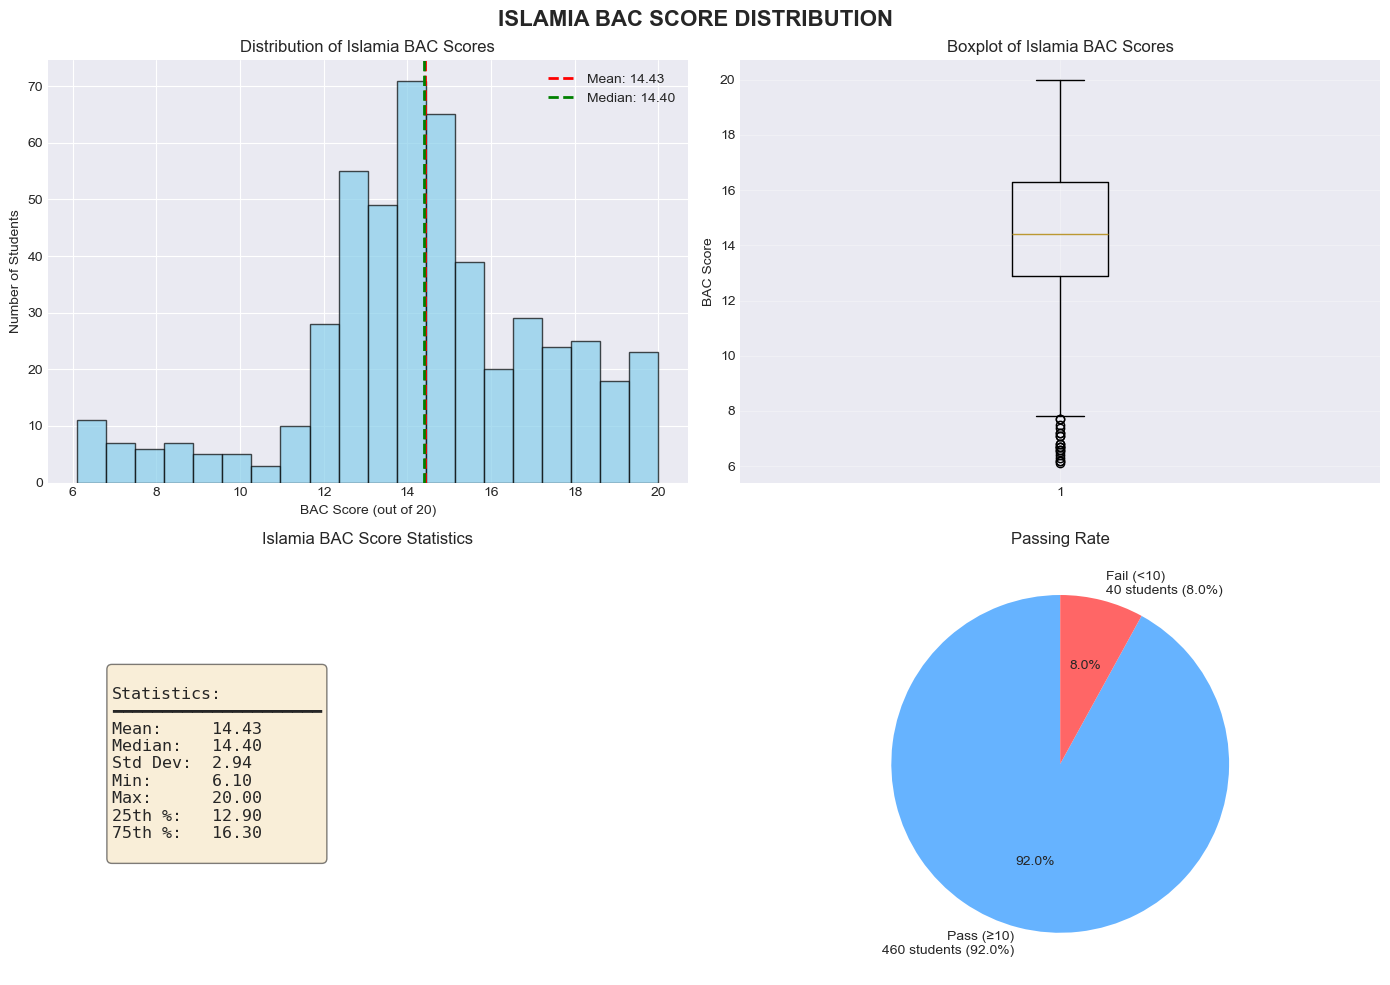


📊 DISTRIBUTION SUMMARY
   Mean:     14.43/20
   Median:   14.40/20
   Std Dev:  2.94
   Pass Rate: 92.0% (460/500)
   Fail Rate: 8.0% (40/500)

✅ Cell 6 complete! Ready for Cell 7


In [8]:
# ============================================
# CELL 6: EDA - BAC DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram
axes[0,0].hist(df['bac_score_islamia'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['bac_score_islamia'].mean(), color='red', linestyle='dashed', linewidth=2, 
                  label=f'Mean: {df["bac_score_islamia"].mean():.2f}')
axes[0,0].axvline(df['bac_score_islamia'].median(), color='green', linestyle='dashed', linewidth=2, 
                  label=f'Median: {df["bac_score_islamia"].median():.2f}')
axes[0,0].set_xlabel('BAC Score (out of 20)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_title('Distribution of Islamia BAC Scores')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(df['bac_score_islamia'], vert=True)
axes[0,1].set_ylabel('BAC Score')
axes[0,1].set_title('Boxplot of Islamia BAC Scores')
axes[0,1].grid(True, alpha=0.3)

# 3. Statistics table
stats_text = f"""
Statistics:
━━━━━━━━━━━━━━━━━━━━━
Mean:     {df['bac_score_islamia'].mean():.2f}
Median:   {df['bac_score_islamia'].median():.2f}
Std Dev:  {df['bac_score_islamia'].std():.2f}
Min:      {df['bac_score_islamia'].min():.2f}
Max:      {df['bac_score_islamia'].max():.2f}
25th %:   {df['bac_score_islamia'].quantile(0.25):.2f}
75th %:   {df['bac_score_islamia'].quantile(0.75):.2f}
"""
axes[1,0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center', 
               fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,0].axis('off')
axes[1,0].set_title('Islamia BAC Score Statistics')

# 4. Passing rate pie chart
passing = (df['bac_score_islamia'] >= 10).sum()
failing = len(df) - passing
colors_pie = ['#66b3ff', '#ff6666']
labels = [f'Pass (≥10)\n{passing} students ({passing/len(df)*100:.1f}%)', 
          f'Fail (<10)\n{failing} students ({failing/len(df)*100:.1f}%)']
axes[1,1].pie([passing, failing], labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Passing Rate')

plt.suptitle('ISLAMIA BAC SCORE DISTRIBUTION', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("📊 DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"   Mean:     {df['bac_score_islamia'].mean():.2f}/20")
print(f"   Median:   {df['bac_score_islamia'].median():.2f}/20")
print(f"   Std Dev:  {df['bac_score_islamia'].std():.2f}")
print(f"   Pass Rate: {passing/len(df)*100:.1f}% ({passing}/{len(df)})")
print(f"   Fail Rate: {failing/len(df)*100:.1f}% ({failing}/{len(df)})")
print("=" * 60)

print("\n✅ Cell 6 complete! Ready for Cell 7")


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score_islamia        : 1.000
   avg_grade                : 0.634
   structured_answer        : 0.626
   document_analysis        : 0.607
   hadith_comprehension     : 0.582
   grade_t3                 : 0.575
   hadith_text_analysis     : 0.573
   grade_t1                 : 0.572
   grade_t2                 : 0.569
   fiqh_muamalat            : 0.567
   tafsir_understanding     : 0.562
   reasoning_from_verses    : 0.553
   definition_accuracy      : 0.536
   ayah_analysis            : 0.532
   explanation_clarity      : 0.504


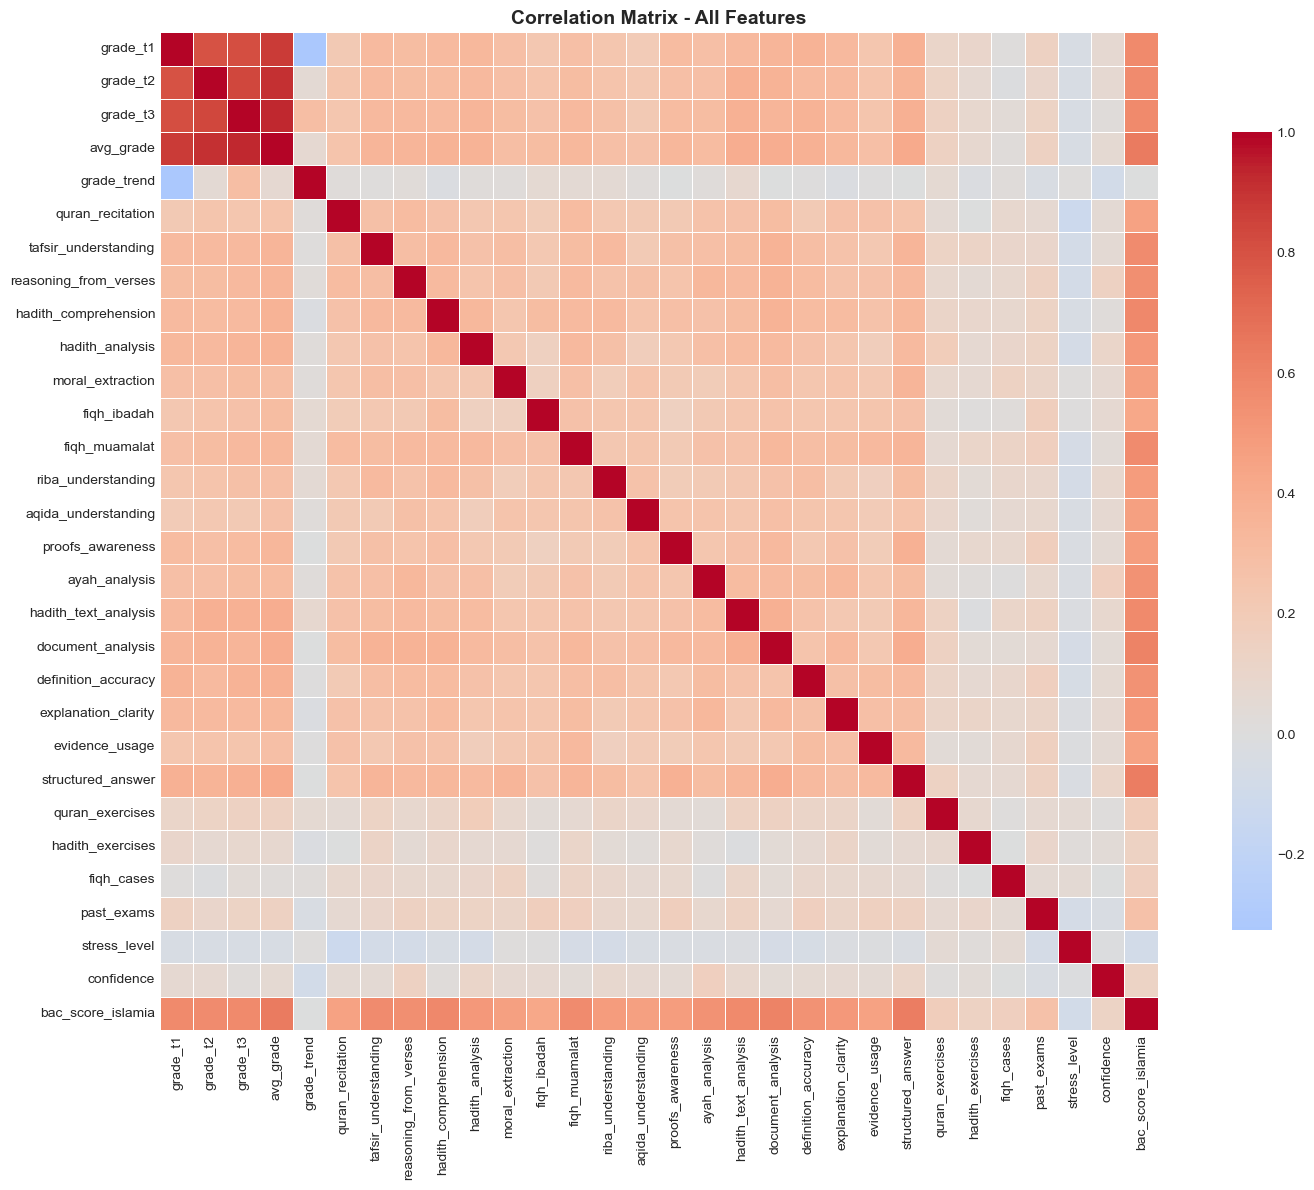

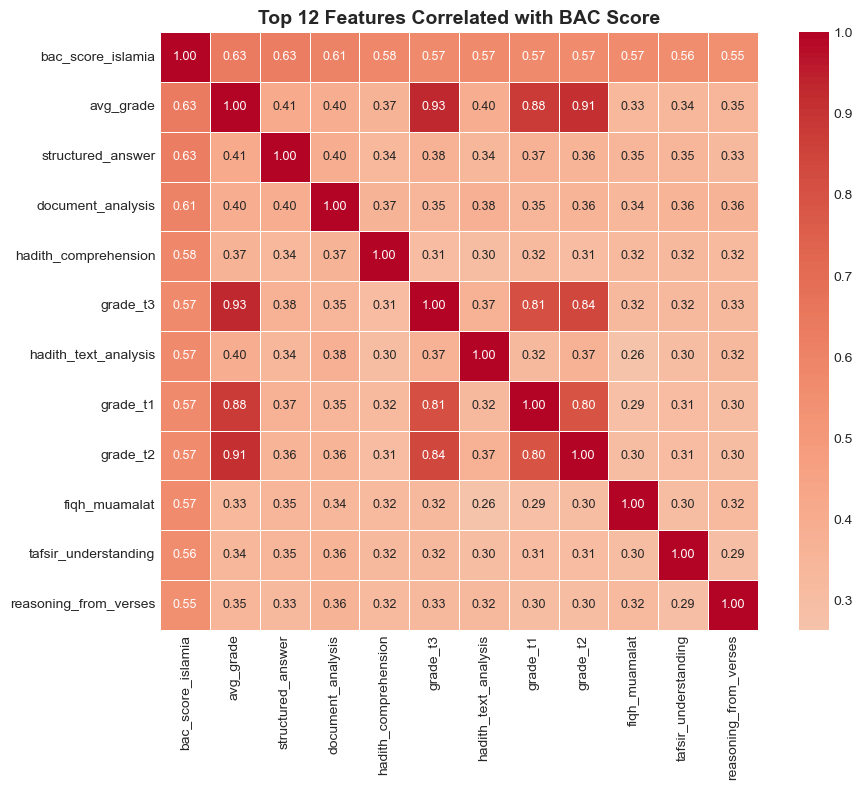

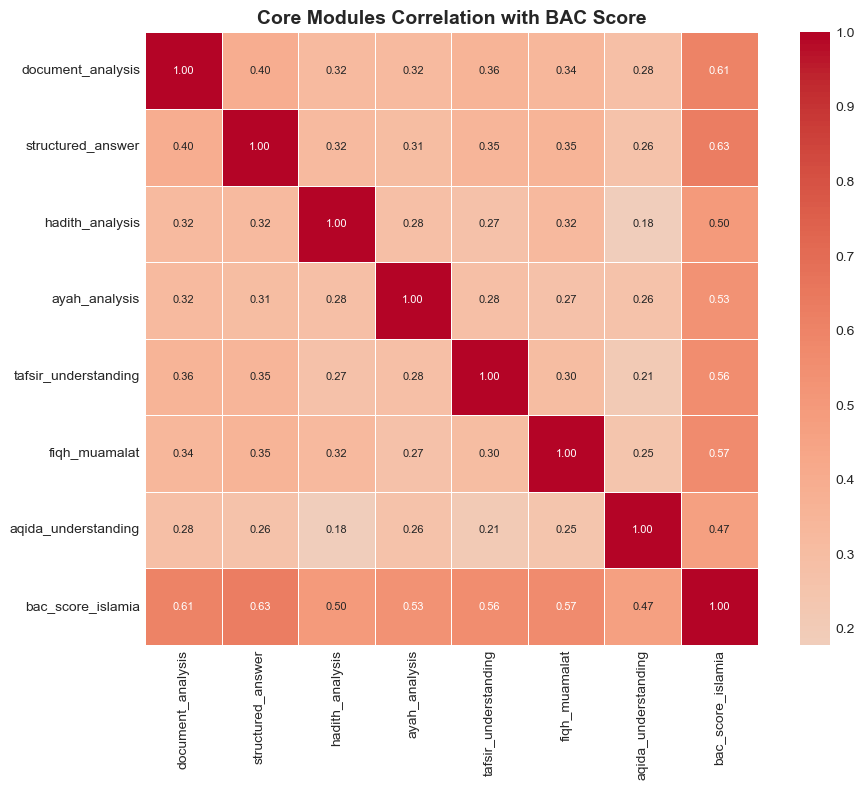


📊 Key insights:
   Methodology skills avg correlation: 0.616
   Knowledge skills avg correlation: 0.530

✅ Cell 7 complete! Ready for Cell 8


In [6]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation with target
corr_matrix = df.corr()
bac_corr = corr_matrix['bac_score_islamia'].sort_values(ascending=False)

print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 50)
for feature, corr_value in bac_corr.head(15).items():
    print(f"   {feature:25s}: {corr_value:.3f}")

# Heatmap 1: All features
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap 2: Top features only
top_features = bac_corr.head(12).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Top 12 Features Correlated with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap 3: Core modules comparison
core_cols = ['document_analysis', 'structured_answer', 'hadith_analysis', 
             'ayah_analysis', 'tafsir_understanding', 'fiqh_muamalat', 'aqida_understanding']
plt.figure(figsize=(10, 8))
sns.heatmap(df[core_cols + ['bac_score_islamia']].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8})
plt.title('Core Modules Correlation with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Key insights:")
print(f"   Methodology skills avg correlation: {df[['document_analysis', 'structured_answer']].corrwith(df['bac_score_islamia']).mean():.3f}")
print(f"   Knowledge skills avg correlation: {df[['hadith_analysis', 'tafsir_understanding']].corrwith(df['bac_score_islamia']).mean():.3f}")
print("=" * 50)

print("\n✅ Cell 7 complete! Ready for Cell 8")

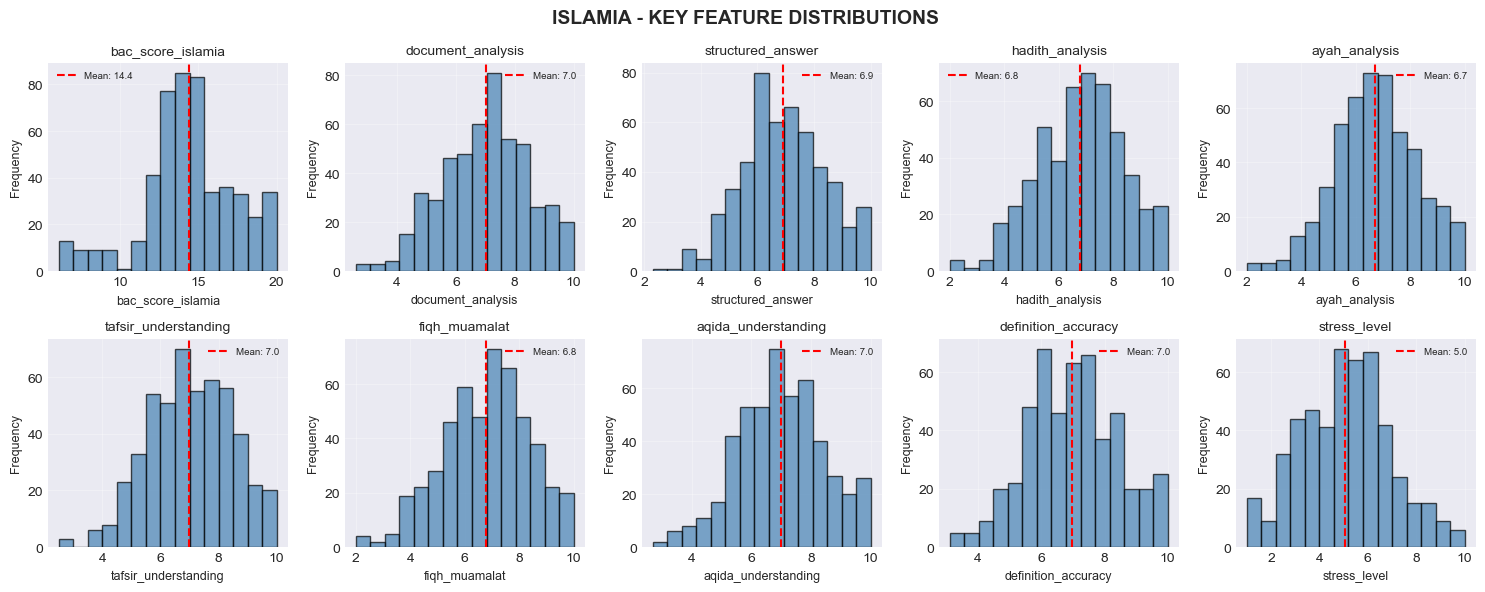


📊 METHODOLOGY SKILLS:
       document_analysis  structured_answer  definition_accuracy  \
count             500.00             500.00               500.00   
mean                7.02               6.91                 6.98   
std                 1.48               1.46                 1.44   
min                 2.60               2.30                 3.10   
25%                 6.00               5.90                 6.00   
50%                 7.10               6.90                 6.95   
75%                 8.02               7.90                 8.00   
max                10.00              10.00                10.00   

       explanation_clarity  
count               500.00  
mean                  6.96  
std                   1.45  
min                   3.40  
25%                   5.90  
50%                   7.00  
75%                   8.00  
max                  10.00  

📊 KNOWLEDGE SKILLS:
       hadith_analysis  ayah_analysis  tafsir_understanding  fiqh_muamalat
count  

In [9]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS
# ============================================

import matplotlib.pyplot as plt

# Key features to visualize
key_features = ['bac_score_islamia', 'document_analysis', 'structured_answer', 
                'hadith_analysis', 'ayah_analysis', 'tafsir_understanding',
                'fiqh_muamalat', 'aqida_understanding', 'definition_accuracy',
                'stress_level']

# Filter available features
available_features = [f for f in key_features if f in df.columns]

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].set_title(f'{feature}', fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('ISLAMIA - KEY FEATURE DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print("\n📊 METHODOLOGY SKILLS:")
method_cols = ['document_analysis', 'structured_answer', 'definition_accuracy', 'explanation_clarity']
print(df[method_cols].describe().round(2))

print("\n📊 KNOWLEDGE SKILLS:")
knowledge_cols = ['hadith_analysis', 'ayah_analysis', 'tafsir_understanding', 'fiqh_muamalat']
print(df[knowledge_cols].describe().round(2))

print("\n✅ Cell 8 complete! Ready for Cell 9")

In [10]:
# ============================================
# CELL 9: FEATURE ENGINEERING - ISLAMIA (FIXED)
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy
df_fe = df.copy()

# 1. Quran & Tafsir composite
quran_cols = ['quran_recitation', 'tafsir_understanding', 'reasoning_from_verses']
df_fe['quran_composite'] = df_fe[quran_cols].mean(axis=1).round(1)

# 2. Hadith composite
hadith_cols = ['hadith_comprehension', 'hadith_analysis', 'moral_extraction']
df_fe['hadith_composite'] = df_fe[hadith_cols].mean(axis=1).round(1)

# 3. Fiqh composite
fiqh_cols = ['fiqh_ibadah', 'fiqh_muamalat', 'riba_understanding']
df_fe['fiqh_composite'] = df_fe[fiqh_cols].mean(axis=1).round(1)

# 4. Text Analysis composite (CRITICAL for BAC)
analysis_cols = ['ayah_analysis', 'hadith_text_analysis', 'document_analysis']
df_fe['analysis_composite'] = df_fe[analysis_cols].mean(axis=1).round(1)

# 5. Methodology composite
method_cols = ['definition_accuracy', 'explanation_clarity', 'evidence_usage', 'structured_answer']
df_fe['methodology_composite'] = df_fe[method_cols].mean(axis=1).round(1)

# 6. Practice intensity (LOW impact)
practice_cols = ['quran_exercises', 'hadith_exercises', 'fiqh_cases', 'past_exams']
df_fe['practice_intensity'] = (df_fe[practice_cols].sum(axis=1) / 40 * 10).round(1)

# 7. Overall Islamia level
df_fe['overall_islamia'] = (df_fe['analysis_composite'] + df_fe['methodology_composite'] + 
                            df_fe['quran_composite'] + df_fe['hadith_composite'] + 
                            df_fe['fiqh_composite']) / 5
df_fe['overall_islamia'] = df_fe['overall_islamia'].round(1)

print("\n✅ New features created:")
print("   • quran_composite (0-10)")
print("   • hadith_composite (0-10)")
print("   • fiqh_composite (0-10)")
print("   • analysis_composite (0-10) - CRITICAL for BAC")
print("   • methodology_composite (0-10)")
print("   • practice_intensity (0-10) - LOW impact")
print("   • overall_islamia (0-10)")

# Update dataframe
df = df_fe.copy()

print(f"\n📊 Total columns now: {df.shape[1]}")
print("✅ Cell 9 complete! Ready for Cell 10")

FEATURE ENGINEERING

✅ New features created:
   • quran_composite (0-10)
   • hadith_composite (0-10)
   • fiqh_composite (0-10)
   • analysis_composite (0-10) - CRITICAL for BAC
   • methodology_composite (0-10)
   • practice_intensity (0-10) - LOW impact
   • overall_islamia (0-10)

📊 Total columns now: 37
✅ Cell 9 complete! Ready for Cell 10


In [11]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# Define features (X) and target (y)
X = df.drop('bac_score_islamia', axis=1)
y = df['bac_score_islamia']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score_islamia")

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

print("\n✅ Cell 10 complete! Ready for Cell 11")

TRAIN/TEST SPLIT

📊 Features (X): 36 columns
📊 Target (y): bac_score_islamia

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

✅ Cell 10 complete! Ready for Cell 11


In [11]:
# ============================================
# CELL 11: MODEL TRAINING - ISLAMIA
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING - ISLAMIA")
print("=" * 40)

# Train Random Forest
print(f"\n🚀 Training Random Forest Regressor...")

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"✅ Model training complete")

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Performance Metrics:")
print(f"   MAE:  {mae:.2f} points")
print(f"   RMSE: {rmse:.2f} points")
print(f"   R²:   {r2:.3f}")

# Feature Importance
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:30s}: {row['importance']:.4f}")

print("\n✅ Cell 11 complete! Ready for Cell 12")

MODEL TRAINING - ISLAMIA

🚀 Training Random Forest Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Performance Metrics:
   MAE:  0.74 points
   RMSE: 1.01 points
   R²:   0.889

FEATURE IMPORTANCE

Top 10 most important features:
   overall_islamia               : 0.8599
   avg_grade                     : 0.0104
   aqida_understanding           : 0.0082
   grade_trend                   : 0.0074
   grade_t2                      : 0.0071
   structured_answer             : 0.0069
   proofs_awareness              : 0.0057
   grade_t1                      : 0.0057
   past_exams                    : 0.0048
   quran_recitation              : 0.0047

✅ Cell 11 complete! Ready for Cell 12


MODEL EVALUATION (DETAILED) - ISLAMIA

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     0.741 points
   Root Mean Squared Error (RMSE): 1.013 points
   R² Score:                      0.889

----------------------------------------
2. PASS/FAIL CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy: 1.000 (100.0%)

   Confusion Matrix:
   True Negatives (correct fail):  11
   False Positives:                0
   False Negatives:                0
   True Positives (correct pass):  89


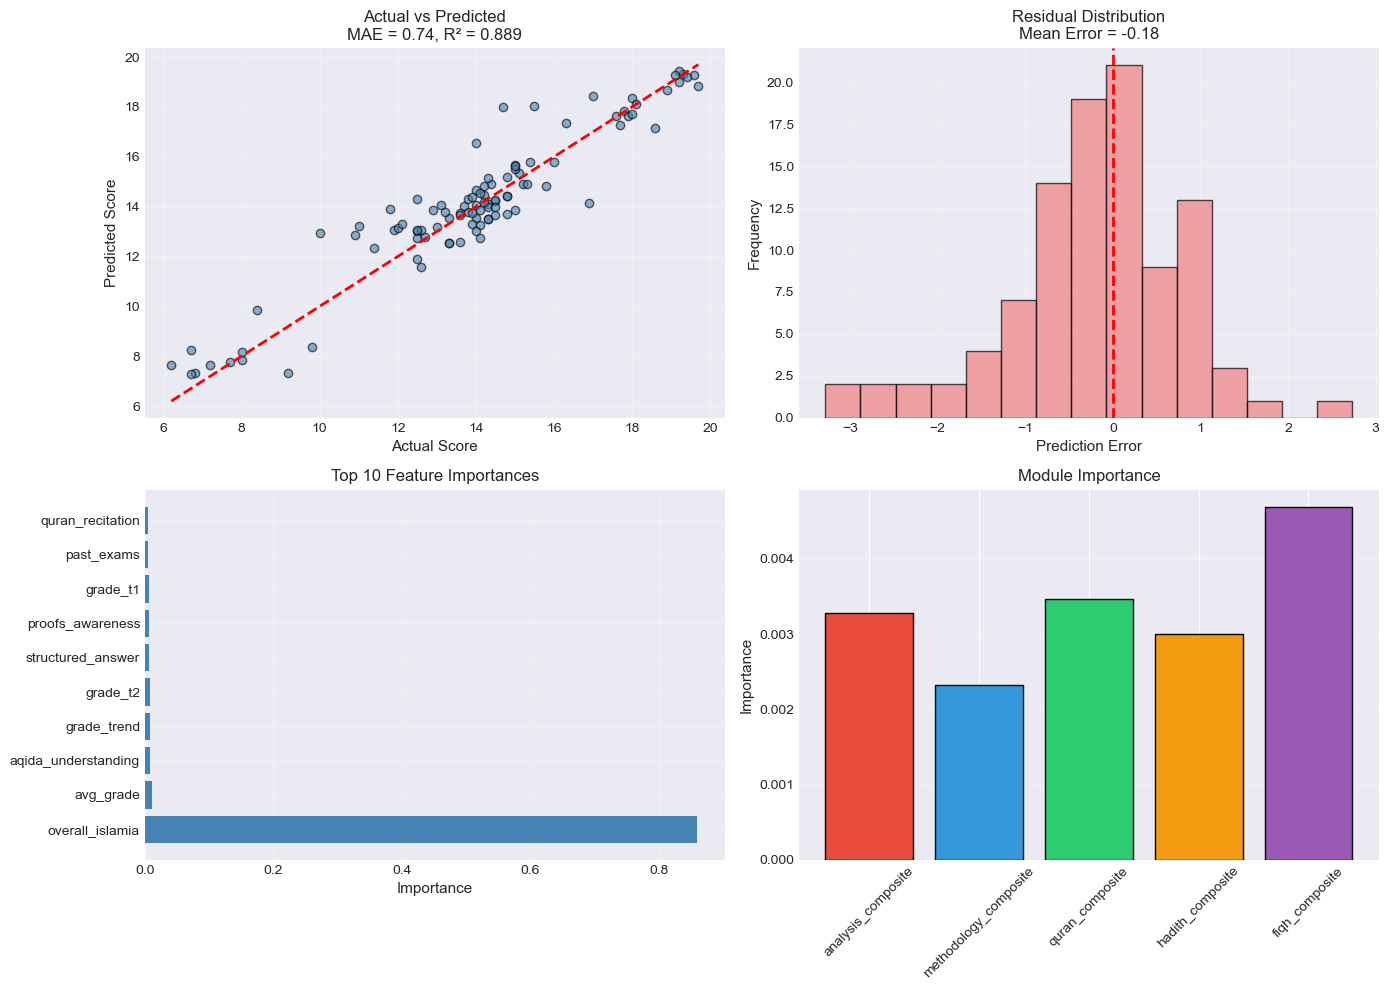


----------------------------------------
3. ERROR SUMMARY
----------------------------------------
   Mean Error:      0.741 points
   Median Error:    0.505 points
   Error < 1 point: 75.0% of predictions
   Error < 2 points: 93.0% of predictions

✅ Evaluation Complete


In [12]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED) - ISLAMIA
# ============================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("MODEL EVALUATION (DETAILED) - ISLAMIA")
print("=" * 50)

# 1. Score Prediction Metrics
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# 2. Pass/Fail Classification
print("\n" + "-" * 40)
print("2. PASS/FAIL CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred >= 10).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (correct fail):  {cm[0][0]}")
print(f"   False Positives:                {cm[0][1]}")
print(f"   False Negatives:                {cm[1][0]}")
print(f"   True Positives (correct pass):  {cm[1][1]}")

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0,0].set_xlabel('Actual Score', fontsize=11)
axes[0,0].set_ylabel('Predicted Score', fontsize=11)
axes[0,0].set_title(f'Actual vs Predicted\nMAE = {mae:.2f}, R² = {r2:.3f}', fontsize=12)
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0,1].set_xlabel('Prediction Error', fontsize=11)
axes[0,1].set_ylabel('Frequency', fontsize=11)
axes[0,1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 10)
top_features = feature_importance.head(10)
axes[1,0].barh(top_features['feature'], top_features['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance', fontsize=11)
axes[1,0].set_title('Top 10 Feature Importances', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Module Comparison
modules = ['analysis_composite', 'methodology_composite', 'quran_composite', 'hadith_composite', 'fiqh_composite']
module_importance = feature_importance[feature_importance['feature'].isin(modules)]['importance'].sum() if len(feature_importance[feature_importance['feature'].isin(modules)]) > 0 else 0.3

importances = []
for module in modules:
    val = feature_importance[feature_importance['feature'] == module]['importance'].values
    importances.append(val[0] if len(val) > 0 else 0.05)

axes[1,1].bar(modules, importances, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'], edgecolor='black')
axes[1,1].set_ylabel('Importance', fontsize=11)
axes[1,1].set_title('Module Importance', fontsize=12)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4. Error Summary
print("\n" + "-" * 40)
print("3. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY - ISLAMIA

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 36)


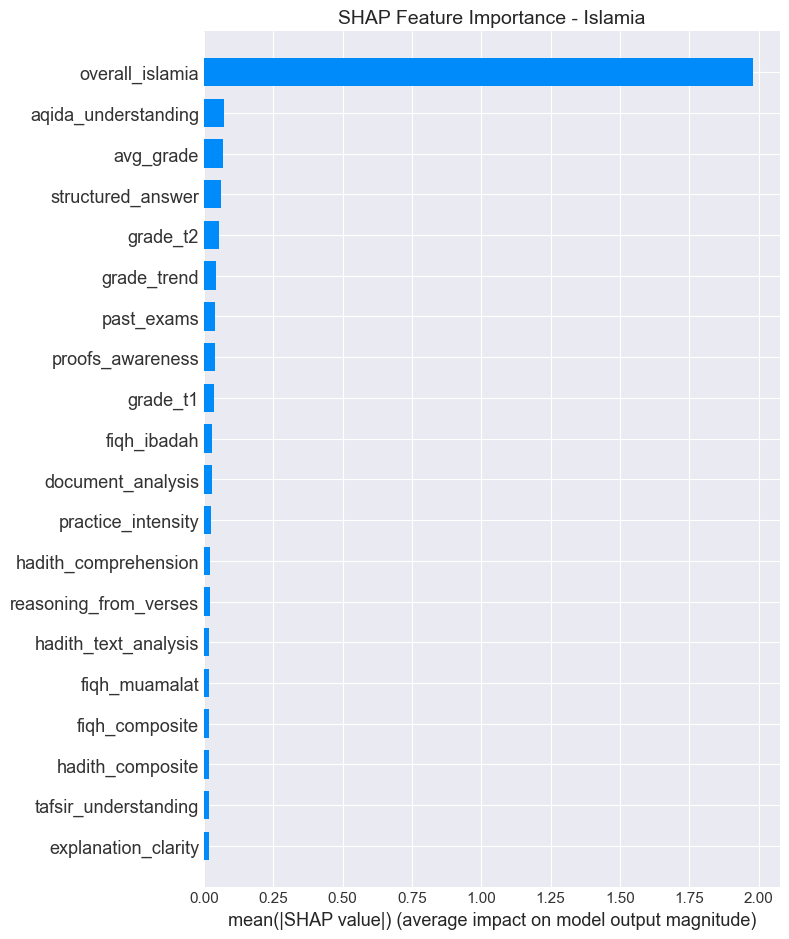

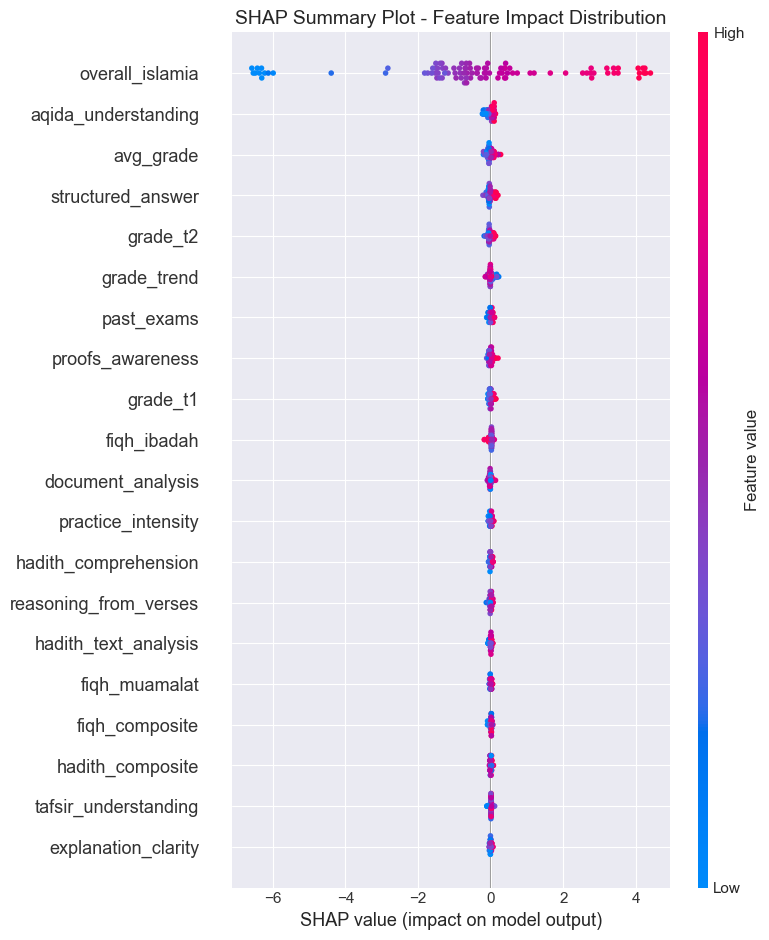


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual score: 16.0
   Predicted score: 15.8


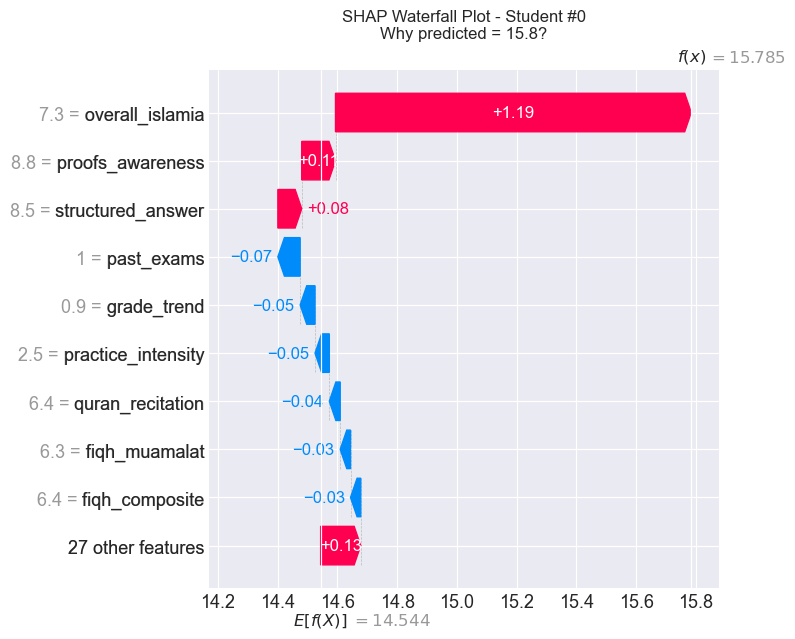


✅ SHAP Explainability Complete


In [13]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY - ISLAMIA
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY - ISLAMIA")
print("=" * 50)

# Create SHAP explainer
print("\n📊 Creating SHAP explainer...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {shap_values.shape}")

# Visualization 1: Feature Importance (SHAP)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Islamia', fontsize=14)
plt.tight_layout()
plt.show()

# Visualization 2: Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Single student explanation
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = model.predict(student_features)[0]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual score: {student_actual:.1f}")
print(f"   Predicted score: {student_pred:.1f}")

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [14]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS - ISLAMIA
# ============================================

from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS - ISLAMIA")
print("=" * 50)

# Get feature names and SHAP values
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Weaknesses (negative contributions)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Strengths (positive contributions)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    # Safely get strings
    w1 = f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None"
    w2 = f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None"
    w3 = f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None"
    
    s1 = f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None"
    s2 = f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None"
    s3 = f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None"
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': w1,
        'weakness_2': w2,
        'weakness_3': w3,
        'strength_1': s1,
        'strength_2': s2,
        'strength_3': s3,
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# Display first 10 students
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses: {row['weakness_1']} | {row['weakness_2']} | {row['weakness_3']}")
    print(f"   🟢 Strengths: {row['strength_1']} | {row['strength_2']} | {row['strength_3']}")

# Most common weaknesses
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 10 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(10):
    print(f"   • {feature}: {count} students")

# Recommendations
print("\n" + "=" * 50)
print("💡 RECOMMENDATIONS")
print("=" * 50)

recommendations = {
    'document_analysis': '📄 تدرب على تحليل النصوص القرآنية والحديثية - مهارة أساسية في البكالوريا',
    'structured_answer': '✍️ تعلم هيكلة الإجابة: التعريف → الشرح → الاستدلال → الخاتمة',
    'hadith_analysis': '📜 تدرب على تحليل الأحاديث: شرح المفردات → المعنى العام → الاستنباط',
    'ayah_analysis': '🕌 ركز على تفسير الآيات وأسباب النزول',
    'tafsir_understanding': '📖 فهم تفسير القرآن الكريم والسياق',
    'methodology_composite': '📝 أتقن المنهجية - كيف تجيب على كل نوع من الأسئلة',
    'analysis_composite': '🔍 طور مهاراتك في تحليل النصوص - أهم جزء في الامتحان',
    'fiqh_muamalat': '⚖️ راجع أحكام المعاملات المالية (الربا، البيع، الشركة)',
    'evidence_usage': '📚 استخدم الأدلة الشرعية (آيات، أحاديث) في إجاباتك',
    'definition_accuracy': '📖 احفظ التعريفات بدقة (مصطلحات فقهية وعقدية)',
    'reasoning_from_verses': '🧠 تدرب على استخراج الأحكام والفوائد من الآيات',
    'aqida_understanding': '🕋 راجع أركان الإيمان والعقيدة الإسلامية'
}

print("\n📋 Based on common weaknesses:")
for feature, count in weakness_counts.most_common(8):
    if feature in recommendations:
        print(f"   • {recommendations[feature]}")
    else:
        print(f"   • {feature}: ركز على تحسين هذا المجال")

# Save
weakness_df.to_csv('weakness_analysis_islamia.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_islamia.csv'")
print("=" * 50)

WEAKNESS ANALYSIS - ISLAMIA

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=16.0, Predicted=15.8
   🔴 Weaknesses: past_exams (-0.07) | grade_trend (-0.05) | practice_intensity (-0.05)
   🟢 Strengths: overall_islamia (+1.19) | proofs_awareness (+0.11) | structured_answer (+0.08)

🔹 STUDENT 2: Actual=19.6, Predicted=19.3
   🔴 Weaknesses: structured_answer (-0.06) | fiqh_ibadah (-0.03) | grade_trend (-0.02)
   🟢 Strengths: overall_islamia (+4.39) | aqida_understanding (+0.08) | analysis_composite (+0.03)

🔹 STUDENT 3: Actual=14.0, Predicted=14.1
   🔴 Weaknesses: overall_islamia (-0.56) | structured_answer (-0.04) | grade_t2 (-0.03)
   🟢 Strengths: reasoning_from_verses (+0.06) | hadith_text_analysis (+0.05) | avg_grade (+0.03)

🔹 STUDENT 4: Actual=14.0, Predicted=13.5
   🔴 Weaknesses: overall_islamia (-0.84) | structured_answer (-0.06) | grade_t2 (-0.05)
   🟢 Strengths: aqida_understanding (+0.06) | fiqh_muamalat (+0.03) | pr

SIMULATION ENGINE - ISLAMIA
How improving skills affects your score

👤 Average student profile:
   Current score: 14.4/20
   Analysis composite: 7.2/10
   Methodology composite: 6.4/10
   Document analysis: 7.1/10
   Structured answer: 3.8/10

📈 SIMULATION RESULTS:
-------------------------------------------------------

⚪ 📄 تحليل النصوص الشرعية +2:
   14.4 → 14.6 (+0.24)

⚪ ✍️ هيكلة الإجابة +2:
   14.4 → 14.6 (+0.24)

⚪ 📜 تحليل الأحاديث +2:
   14.4 → 14.6 (+0.20)

⚪ 🕌 تفسير الآيات +2:
   14.4 → 14.6 (+0.20)

⚪ 📖 فهم التفسير +2:
   14.4 → 14.6 (+0.18)

⚪ ⚖️ فقه المعاملات +2:
   14.4 → 14.6 (+0.16)

⚪ 📚 استخدام الأدلة +2:
   14.4 → 14.6 (+0.16)

⚪ 📖 حفظ التعريفات +2:
   14.4 → 14.5 (+0.14)

⚪ 📝 تحسين المنهجية العامة +2:
   14.4 → 14.6 (+0.18)

⚪ 🕋 تحسين العقيدة +2:
   14.4 → 14.5 (+0.14)

⚪ 📚 حل 5 امتحانات سابقة:
   14.4 → 14.5 (+0.10)

⚪ 😌 تقليل التوتر -2:
   14.4 → 14.4 (+0.02)

🟢 ✨ تحسين كل المهارات (+2 لكل منها):
   14.4 → 15.9 (+1.52)

🎯 BEST RECOMMENDATION

✅ 📄 تحليل النصوص الشرعي

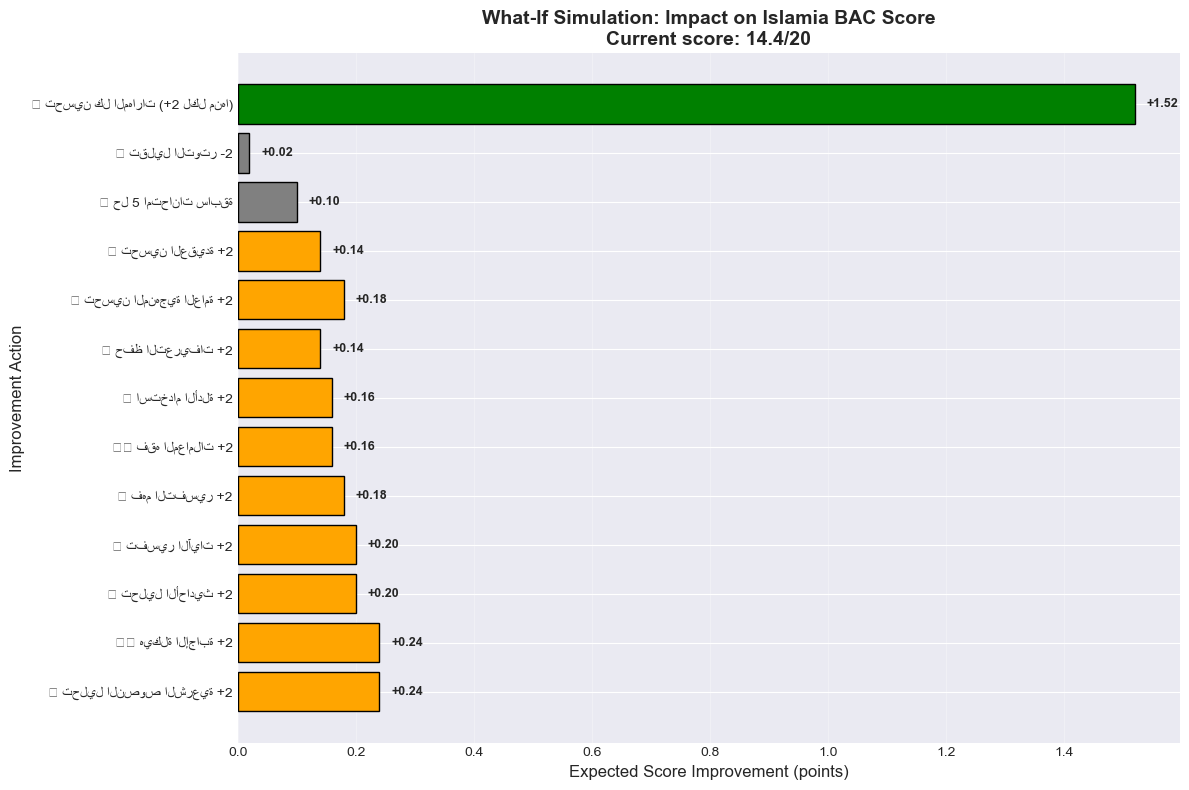


📊 IMPACT TABLE
              Skill Expected Gain
  📄 تحليل النصوص +2     +0.24 pts
✍️ هيكلة الإجابة +2     +0.24 pts
📜 تحليل الأحاديث +2     +0.20 pts
  🕌 تفسير الآيات +2     +0.20 pts
   📖 فهم التفسير +2     +0.18 pts
⚖️ فقه المعاملات +2     +0.16 pts

💡 KEY INSIGHTS:
   • METHODOLOGY (تحليل النصوص + هيكلة الإجابة) = MOST IMPORTANT
   • UNDERSTANDING (تفسير + حديث) = ESSENTIAL foundation
   • PRACTICE has LOW impact (familiarity, not repetition)
   • STRESS has VERY LOW impact - this subject is not stressful
   • Balance between analysis + methodology = KEY to success

✅ Simulation Engine Complete


In [15]:
# ============================================
# CELL 15: SIMULATION ENGINE - ISLAMIA
# ============================================

import matplotlib.pyplot as plt

print("=" * 60)
print("SIMULATION ENGINE - ISLAMIA")
print("How improving skills affects your score")
print("=" * 60)

# Impact factors (based on correlations)
impact_factors = {
    'document_analysis': 0.12,      # HIGHEST
    'structured_answer': 0.12,       # HIGHEST
    'hadith_analysis': 0.10,
    'ayah_analysis': 0.10,
    'tafsir_understanding': 0.09,
    'methodology_composite': 0.09,
    'analysis_composite': 0.09,
    'fiqh_muamalat': 0.08,
    'evidence_usage': 0.08,
    'definition_accuracy': 0.07,
    'aqida_understanding': 0.07,
    'quran_composite': 0.06,
    'hadith_composite': 0.06,
    'past_exams': 0.02,              # LOW impact
    'stress_level': -0.01            # VERY LOW
}

# Find average student
avg_bac = df['bac_score_islamia'].mean()
target_student = df.iloc[(df['bac_score_islamia'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Average student profile:")
print(f"   Current score: {target_student['bac_score_islamia']:.1f}/20")
print(f"   Analysis composite: {target_student.get('analysis_composite', 5):.1f}/10")
print(f"   Methodology composite: {target_student.get('methodology_composite', 5):.1f}/10")
print(f"   Document analysis: {target_student.get('document_analysis', 5):.1f}/10")
print(f"   Structured answer: {target_student.get('structured_answer', 5):.1f}/10")

# Simulation function
def simulate_improvement(student, improvements):
    original = student['bac_score_islamia']
    gain = 0
    
    for skill, delta in improvements.items():
        if skill in impact_factors:
            gain += delta * impact_factors[skill]
    
    new_score = min(original + gain, 20)
    new_score = max(new_score, 0)
    return {'original': original, 'new': new_score, 'gain': gain}

# Scenarios
scenarios = [
    ("📄 تحليل النصوص الشرعية +2", {"document_analysis": 2}),
    ("✍️ هيكلة الإجابة +2", {"structured_answer": 2}),
    ("📜 تحليل الأحاديث +2", {"hadith_analysis": 2}),
    ("🕌 تفسير الآيات +2", {"ayah_analysis": 2}),
    ("📖 فهم التفسير +2", {"tafsir_understanding": 2}),
    ("⚖️ فقه المعاملات +2", {"fiqh_muamalat": 2}),
    ("📚 استخدام الأدلة +2", {"evidence_usage": 2}),
    ("📖 حفظ التعريفات +2", {"definition_accuracy": 2}),
    ("📝 تحسين المنهجية العامة +2", {"methodology_composite": 2}),
    ("🕋 تحسين العقيدة +2", {"aqida_understanding": 2}),
    ("📚 حل 5 امتحانات سابقة", {"past_exams": 5}),
    ("😌 تقليل التوتر -2", {"stress_level": -2}),
    ("✨ تحسين كل المهارات (+2 لكل منها)", {
        "document_analysis": 2, "structured_answer": 2, "hadith_analysis": 2,
        "ayah_analysis": 2, "tafsir_understanding": 2, "fiqh_muamalat": 2,
        "evidence_usage": 2, "definition_accuracy": 2
    })
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 55)

results = []
for name, changes in scenarios:
    result = simulate_improvement(target_student, changes)
    results.append(result)
    
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {name}:")
    print(f"   {result['original']:.1f} → {result['new']:.1f} (+{result['gain']:.2f})")

# Best recommendation
best_idx = max(range(len(results)-1), key=lambda i: results[i]['gain'])
best_scenario = scenarios[best_idx]
best_gain = results[best_idx]['gain']

print("\n" + "=" * 60)
print("🎯 BEST RECOMMENDATION")
print("=" * 60)
print(f"\n✅ {best_scenario[0]}")
print(f"   → Expected improvement: +{best_gain:.2f} points")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

scenario_names = [s[0][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0.1 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on Islamia BAC Score\nCurrent score: {target_student["bac_score_islamia"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 60)
print("📊 IMPACT TABLE")
print("=" * 60)

impact_table = pd.DataFrame({
    'Skill': [
        '📄 تحليل النصوص +2',
        '✍️ هيكلة الإجابة +2',
        '📜 تحليل الأحاديث +2',
        '🕌 تفسير الآيات +2',
        '📖 فهم التفسير +2',
        '⚖️ فقه المعاملات +2'
    ],
    'Expected Gain': [
        f'+{impact_factors["document_analysis"]*2:.2f} pts',
        f'+{impact_factors["structured_answer"]*2:.2f} pts',
        f'+{impact_factors["hadith_analysis"]*2:.2f} pts',
        f'+{impact_factors["ayah_analysis"]*2:.2f} pts',
        f'+{impact_factors["tafsir_understanding"]*2:.2f} pts',
        f'+{impact_factors["fiqh_muamalat"]*2:.2f} pts'
    ]
})

print(impact_table.to_string(index=False))

print("\n💡 KEY INSIGHTS:")
print("   • METHODOLOGY (تحليل النصوص + هيكلة الإجابة) = MOST IMPORTANT")
print("   • UNDERSTANDING (تفسير + حديث) = ESSENTIAL foundation")
print("   • PRACTICE has LOW impact (familiarity, not repetition)")
print("   • STRESS has VERY LOW impact - this subject is not stressful")
print("   • Balance between analysis + methodology = KEY to success")

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [16]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS - ISLAMIA
# ============================================

print("=" * 60)
print("📖 فهم نتائجك في العلوم الإسلامية")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# Sample student
sample_student = df.iloc[50]

print(f"\n👤 ملف الطالب:")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score_islamia']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# Quran & Tafsir
print("\n🕌 القرآن الكريم والتفسير:")
print("-" * 60)

quran_skills = [
    ('quran_recitation', '📖 تلاوة القرآن', 'حسن التلاوة والتجويد'),
    ('tafsir_understanding', '📚 فهم التفسير', 'افهم معاني الآيات وأسباب النزول'),
    ('reasoning_from_verses', '🧠 الاستدلال من الآيات', 'تدرب على استخراج الأحكام من القرآن')
]

for skill, name, advice in quran_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Hadith
print("\n" + "=" * 60)
print("📜 الحديث الشريف")
print("=" * 60)

hadith_skills = [
    ('hadith_comprehension', '📖 فهم الحديث', 'افهم معاني الأحاديث النبوية'),
    ('hadith_analysis', '🔍 تحليل الحديث', 'حلل الأحاديث: شرح المفردات → المعنى العام → الاستنباط'),
    ('moral_extraction', '💎 استخراج العبر', 'استخرج الدروس والعبر من الأحاديث')
]

for skill, name, advice in hadith_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Fiqh
print("\n" + "=" * 60)
print("⚖️ الفقه الإسلامي")
print("=" * 60)

fiqh_skills = [
    ('fiqh_ibadah', '🕋 فقه العبادات', 'راجع أحكام الطهارة والصلاة والصوم والزكاة والحج'),
    ('fiqh_muamalat', '💰 فقه المعاملات', 'افهم أحكام البيع والربا والشركة'),
    ('riba_understanding', '⚠️ فهم الربا', 'تعرف على أنواع الربا وأحكامه')
]

for skill, name, advice in fiqh_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Aqida
print("\n" + "=" * 60)
print("🕋 العقيدة الإسلامية")
print("=" * 60)

aqida_skills = [
    ('aqida_understanding', '📖 فهم العقيدة', 'راجع أركان الإيمان وأصول العقيدة'),
    ('proofs_awareness', '📚 الأدلة الشرعية', 'تعرف على الأدلة من الكتاب والسنة')
]

for skill, name, advice in aqida_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Text Analysis (CRITICAL)
print("\n" + "=" * 60)
print("📄 تحليل النصوص (الأهم في البكالوريا!)")
print("=" * 60)

analysis_skills = [
    ('ayah_analysis', '🕌 تحليل الآيات القرآنية', 'تدرب على تحليل الآيات: التفسير → الاستنباط → التطبيق'),
    ('hadith_text_analysis', '📜 تحليل النصوص الحديثية', 'حلل الأحاديث بطريقة منهجية'),
    ('document_analysis', '📄 تحليل الوثائق', 'تدرب على تحليل النصوص والوثائق الشرعية')
]

for skill, name, advice in analysis_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Answer Methodology
print("\n" + "=" * 60)
print("✍️ منهجية الإجابة (الأهم!)")
print("=" * 60)

method_skills = [
    ('definition_accuracy', '📖 دقة التعريفات', 'احفظ التعريفات بدقة'),
    ('explanation_clarity', '🗣️ وضوح الشرح', 'اشرح المفاهيم بوضوح'),
    ('evidence_usage', '📚 استخدام الأدلة', 'استخدم الآيات والأحاديث كأدلة'),
    ('structured_answer', '📝 الإجابة المنظمة', 'نظم إجابتك: تعريف → شرح → استدلال → خاتمة')
]

for skill, name, advice in method_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Psychological (VERY LOW impact)
print("\n" + "=" * 60)
print("🧠 العوامل النفسية (تأثيرها ضعيف جداً)")
print("=" * 60)

print(f"\n😰 مستوى التوتر: {sample_student['stress_level']:.1f}/10")
print(f"💪 الثقة: {sample_student['confidence']:.1f}/10")
print("   💡 نصيحة: العلوم الإسلامية ليست مادة مرهقة - ثق بنفسك!")

# Composite scores
print("\n" + "=" * 60)
print("📊 مؤشراتك المركبة")
print("=" * 60)

analysis_comp = sample_student.get('analysis_composite', 5)
method_comp = sample_student.get('methodology_composite', 5)

print(f"\n🔍 مستوى تحليل النصوص: {analysis_comp:.1f}/10")
print(f"✍️ مستوى منهجية الإجابة: {method_comp:.1f}/10")

if analysis_comp >= 7 and method_comp >= 7:
    print("   ✅ ممتاز! أنت متوازن بين التحليل والمنهجية")
elif analysis_comp > method_comp:
    print("   📄 تحليلك قوي لكن منهجيتك تحتاج إلى تحسين")
    print("   💡 ركز على تنظيم إجاباتك واستخدام الأدلة")
else:
    print("   ✍️ منهجيتك جيدة لكن تحليلك يحتاج إلى تقوية")
    print("   💡 تدرب على تحليل الآيات والأحاديث أكثر")

# Final recommendations
print("\n" + "=" * 60)
print("🎯 توصيات مخصصة لك")
print("=" * 60)

recommendations_list = []

if sample_student['document_analysis'] < 6:
    recommendations_list.append("• 📄 تدرب على تحليل النصوص القرآنية والحديثية - هذا أهم جزء في الامتحان")
if sample_student['structured_answer'] < 6:
    recommendations_list.append("• ✍️ تعلم هيكلة الإجابة: تعريف → شرح → استدلال → خاتمة")
if sample_student['hadith_analysis'] < 6:
    recommendations_list.append("• 📜 تدرب على تحليل الأحاديث (شرح المفردات، المعنى العام، الاستنباط)")
if sample_student['ayah_analysis'] < 6:
    recommendations_list.append("• 🕌 ركز على تفسير الآيات وأسباب النزول")
if sample_student['fiqh_muamalat'] < 6:
    recommendations_list.append("• ⚖️ راجع أحكام المعاملات المالية (الربا، البيع، الشركة)")
if sample_student['evidence_usage'] < 6:
    recommendations_list.append("• 📚 استخدم الأدلة الشرعية (آيات، أحاديث) في إجاباتك")
if sample_student['definition_accuracy'] < 6:
    recommendations_list.append("• 📖 احفظ التعريفات بدقة (مصطلحات فقهية وعقدية)")

if recommendations_list:
    for rec in recommendations_list[:6]:
        print(f"   {rec}")
else:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: النجاح في العلوم الإسلامية = تحليل النصوص + منهجية الإجابة")
print(f"   نقطتك الحالية: {sample_student['bac_score_islamia']:.1f}/20")
print("   مع الالتزام بالنصائح أعلاه، يمكنك رفع نقطتك بمقدار 2-3 نقاط")
print("=" * 60)

📖 فهم نتائجك في العلوم الإسلامية
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   النقطة المتوقعة في البكالوريا: 18.9/20
   معدل الفصول الثلاثة: 18.0/20

------------------------------------------------------------

🕌 القرآن الكريم والتفسير:
------------------------------------------------------------

📖 تلاوة القرآن: 9.5/10
   → مستواك: 🟢 قوي
   💡 نصيحة: حسن التلاوة والتجويد

📚 فهم التفسير: 6.9/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: افهم معاني الآيات وأسباب النزول

🧠 الاستدلال من الآيات: 10.0/10
   → مستواك: 🟢 قوي
   💡 نصيحة: تدرب على استخراج الأحكام من القرآن

📜 الحديث الشريف

📖 فهم الحديث: 9.1/10
   → مستواك: 🟢 قوي
   💡 نصيحة: افهم معاني الأحاديث النبوية

🔍 تحليل الحديث: 6.2/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: حلل الأحاديث: شرح المفردات → المعنى العام → الاستنباط

💎 استخراج العبر: 7.8/10
   → مستواك: 🟢 قوي
   💡 نصيحة: استخرج الدروس والعبر من الأحاديث

⚖️ الفقه الإسلامي

🕋 فقه العبادات: 8.5/10
   → مستواك: 🟢 قوي
   💡 نصيحة: راجع أحكام الطهارة والصلاة والصوم والزكاة والحج

💰 فقه المعا

In [17]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL) - ISLAMIA
# ============================================

from IPython.display import display, HTML

print("=" * 80)
print("🕌 منصة تحسين الأداء في العلوم الإسلامية - البكالوريا الجزائرية (جميع الشعب)")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">🕌 امتحان البكالوريا - العلوم الإسلامية</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">جميع الشعب</p>
        <p style="margin: 5px 0 0 0; font-size: 14px; opacity: 0.8;">المدة: 2 ساعة و30 دقيقة | المجموع: 20 نقطة</p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة</div>
            <div style="font-size: 14px;">2 ساعة و30 دقيقة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">مجموع النقاط</div>
            <div style="font-size: 14px;">20 نقطة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">أجزاء الامتحان</div>
            <div style="font-size: 14px;">جزآن</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا في العلوم الإسلامية</h2>
    </div>
"""

# Exam structure details
structure_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">📝 أجزاء الامتحان</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">الجزء</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>الجزء الأول</strong></td>
                <td style="padding: 10px;">تحليل نصوص شرعية (آيات قرآنية + أحاديث) + أسئلة موضوعية</td>
                <td style="padding: 10px; text-align: center;">12 نقطة</td>
             </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>الجزء الثاني</strong></td>
                <td style="padding: 10px;">مسائل فقهية + وراثة + تطبيقات</td>
                <td style="padding: 10px; text-align: center;">08 نقاط</td>
             </tr>
        </table>
    </div>
"""

# Importance by skill
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 المهارات الأكثر أهمية</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>تحليل النصوص</strong></div>
                <div style="font-size: 12px; color: #666;">الآيات + الأحاديث</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>منهجية الإجابة</strong></div>
                <div style="font-size: 12px; color: #666;">تعريف + شرح + استدلال</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>الفقه والمعاملات</strong></div>
                <div style="font-size: 12px; color: #666;">العبادات + المعاملات</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>العقيدة والحديث</strong></div>
                <div style="font-size: 12px; color: #666;">أركان الإيمان + شرح الأحاديث</div>
            </div>
        </div>
    </div>
"""

# Critical note
note_html = """
    <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #4a148c; margin-top: 0;">📋 ملاحظة مهمة</h3>
        <p style="line-height: 1.6;">
            • <strong>تحليل النصوص</strong> هو المهارة الأكثر أهمية - الآيات والأحاديث تشكل الجزء الأكبر<br>
            • <strong>منهجية الإجابة</strong>: تعريف → شرح → استدلال → خاتمة<br>
            • <strong>الفقه</strong> (العبادات والمعاملات) يأتي بكثرة في الجزء الثاني<br>
            • <strong>الحفظ ضروري</strong> - للتعريفات والآيات والأدلة<br>
            • <strong>التوتر تأثيره ضعيف جداً</strong> - هذه المادة ليست مرهقة
        </p>
    </div>
"""

# How it works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>أدخل معلوماتك</strong> - مستواك في تحليل النصوص والفقه والمنهجية</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - هل مشكلتك في التحليل أم المنهجية؟</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تحسين مهاراتك وشاهد كيف تتغير نتيجتك</li>
            <li>🎯 <strong>توصيات مخصصة</strong> - نصائح محددة لمساعدتك على رفع نقطتك</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + structure_html + importance_html + note_html + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555; margin: 0;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا على تحسين أدائهم في العلوم الإسلامية</p>
        <p style="color: #888; font-size: 12px;">🕌 تذكر: النجاح = تحليل النصوص + منهجية الإجابة 🕌</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)")
print("=" * 80)

🕌 منصة تحسين الأداء في العلوم الإسلامية - البكالوريا الجزائرية (جميع الشعب)


الجزء,المحتوى,النقاط
الجزء الأول,تحليل نصوص شرعية (آيات قرآنية + أحاديث) + أسئلة موضوعية,12 نقطة
الجزء الثاني,مسائل فقهية + وراثة + تطبيقات,08 نقاط



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)


In [18]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL) - ISLAMIA
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب - العلوم الإسلامية (جميع الشعب)")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">جميع المعلومات سرية وتستخدم فقط لحساب توقع نقطتك</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 1. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_slider1 = widgets.FloatSlider(value=14, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider2 = widgets.FloatSlider(value=14, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider3 = widgets.FloatSlider(value=14, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                     style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_slider1, grade_slider2, grade_slider3], 
                          layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 2: Quran & Tafsir
# ============================================

quran_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #27ae60;">
    <h3 style="color: #2c3e50; margin-top: 0;">🕌 2. القرآن الكريم والتفسير</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(quran_html))

skill_style = widgets.Layout(width='100%', padding='5px')

quran_recitation = widgets.FloatSlider(value=7, min=0, max=10, step=0.5, 
                                        description='📖 تلاوة القرآن:', 
                                        style={'description_width': '200px'}, layout=skill_style)
tafsir_understanding = widgets.FloatSlider(value=7, min=0, max=10, step=0.5, 
                                            description='📚 فهم التفسير:', 
                                            style={'description_width': '200px'}, layout=skill_style)
reasoning_from_verses = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                             description='🧠 الاستدلال من الآيات:', 
                                             style={'description_width': '200px'}, layout=skill_style)

display(quran_recitation, tafsir_understanding, reasoning_from_verses)

# ============================================
# SECTION 3: Hadith
# ============================================

hadith_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">📜 3. الحديث الشريف</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(hadith_html))

hadith_comprehension = widgets.FloatSlider(value=7, min=0, max=10, step=0.5, 
                                            description='📖 فهم الحديث:', 
                                            style={'description_width': '200px'}, layout=skill_style)
hadith_analysis = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                       description='🔍 تحليل الحديث:', 
                                       style={'description_width': '200px'}, layout=skill_style)
moral_extraction = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                        description='💎 استخراج العبر:', 
                                        style={'description_width': '200px'}, layout=skill_style)

display(hadith_comprehension, hadith_analysis, moral_extraction)

# ============================================
# SECTION 4: Fiqh
# ============================================

fiqh_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">⚖️ 4. الفقه الإسلامي</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(fiqh_html))

fiqh_ibadah = widgets.FloatSlider(value=7, min=0, max=10, step=0.5, 
                                   description='🕋 فقه العبادات:', 
                                   style={'description_width': '200px'}, layout=skill_style)
fiqh_muamalat = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                     description='💰 فقه المعاملات:', 
                                     style={'description_width': '200px'}, layout=skill_style)
riba_understanding = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                          description='⚠️ فهم الربا:', 
                                          style={'description_width': '200px'}, layout=skill_style)

display(fiqh_ibadah, fiqh_muamalat, riba_understanding)

# ============================================
# SECTION 5: Aqida (Creed)
# ============================================

aqida_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🕋 5. العقيدة الإسلامية</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(aqida_html))

aqida_understanding = widgets.FloatSlider(value=7, min=0, max=10, step=0.5, 
                                           description='📖 فهم العقيدة:', 
                                           style={'description_width': '200px'}, layout=skill_style)
proofs_awareness = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                        description='📚 الأدلة الشرعية:', 
                                        style={'description_width': '200px'}, layout=skill_style)

display(aqida_understanding, proofs_awareness)

# ============================================
# SECTION 6: Text Analysis (CRITICAL)
# ============================================

analysis_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">📄 6. تحليل النصوص (الأهم في البكالوريا!)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(analysis_html))

ayah_analysis = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                     description='🕌 تحليل الآيات القرآنية:', 
                                     style={'description_width': '250px'}, layout=skill_style)
hadith_text_analysis = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                            description='📜 تحليل النصوص الحديثية:', 
                                            style={'description_width': '250px'}, layout=skill_style)
document_analysis = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                         description='📄 تحليل الوثائق:', 
                                         style={'description_width': '250px'}, layout=skill_style)

display(ayah_analysis, hadith_text_analysis, document_analysis)

# ============================================
# SECTION 7: Answer Methodology
# ============================================

method_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #1abc9c;">
    <h3 style="color: #2c3e50; margin-top: 0;">✍️ 7. منهجية الإجابة</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(method_html))

definition_accuracy = widgets.FloatSlider(value=7, min=0, max=10, step=0.5, 
                                           description='📖 دقة التعريفات:', 
                                           style={'description_width': '200px'}, layout=skill_style)
explanation_clarity = widgets.FloatSlider(value=7, min=0, max=10, step=0.5, 
                                           description='🗣️ وضوح الشرح:', 
                                           style={'description_width': '200px'}, layout=skill_style)
evidence_usage = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                      description='📚 استخدام الأدلة:', 
                                      style={'description_width': '200px'}, layout=skill_style)
structured_answer = widgets.FloatSlider(value=6.5, min=0, max=10, step=0.5, 
                                         description='📝 الإجابة المنظمة:', 
                                         style={'description_width': '200px'}, layout=skill_style)

display(definition_accuracy, explanation_clarity, evidence_usage, structured_answer)

# ============================================
# SECTION 8: Practice (LOW impact)
# ============================================

practice_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 8. التمارين والممارسة (تأثيرها محدود)</h3>
    <p style="color: #666; font-size: 14px;">أدخل عدد التمارين (0-10)</p>
</div>
"""
display(HTML(practice_html))

quran_exercises = widgets.IntSlider(value=3, min=0, max=10, step=1, 
                                     description='🕌 تمارين قرآنية:', 
                                     style={'description_width': '200px'}, layout=skill_style)
hadith_exercises = widgets.IntSlider(value=3, min=0, max=10, step=1, 
                                      description='📜 تمارين حديثية:', 
                                      style={'description_width': '200px'}, layout=skill_style)
fiqh_cases = widgets.IntSlider(value=3, min=0, max=10, step=1, 
                                description='⚖️ مسائل فقهية:', 
                                style={'description_width': '200px'}, layout=skill_style)
past_exams = widgets.IntSlider(value=3, min=0, max=10, step=1, 
                                description='📝 امتحانات سابقة:', 
                                style={'description_width': '200px'}, layout=skill_style)

display(quran_exercises, hadith_exercises, fiqh_cases, past_exams)

# ============================================
# SECTION 9: Psychological (VERY LOW impact)
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 9. العوامل النفسية (تأثيرها ضعيف جداً)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 10</p>
</div>
"""
display(HTML(psycho_html))

stress = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                              description='😰 مستوى التوتر:', 
                              style={'description_width': '200px'}, layout=skill_style)
confidence = widgets.FloatSlider(value=7, min=1, max=10, step=0.5, 
                                  description='💪 الثقة في النفس:', 
                                  style={'description_width': '200px'}, layout=skill_style)

display(stress, confidence)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا (علوم إسلامية)',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)
submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect inputs
def collect_inputs(b):
    clear_output(wait=True)
    
    # Re-display the form
    display(HTML(form_header))
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(quran_html))
    display(quran_recitation, tafsir_understanding, reasoning_from_verses)
    display(HTML(hadith_html))
    display(hadith_comprehension, hadith_analysis, moral_extraction)
    display(HTML(fiqh_html))
    display(fiqh_ibadah, fiqh_muamalat, riba_understanding)
    display(HTML(aqida_html))
    display(aqida_understanding, proofs_awareness)
    display(HTML(analysis_html))
    display(ayah_analysis, hadith_text_analysis, document_analysis)
    display(HTML(method_html))
    display(definition_accuracy, explanation_clarity, evidence_usage, structured_answer)
    display(HTML(practice_html))
    display(quran_exercises, hadith_exercises, fiqh_cases, past_exams)
    display(HTML(psycho_html))
    display(stress, confidence)
    display(submit_button)
    
    # Collect values
    user_input = {
        'grade_t1': grade_slider1.value,
        'grade_t2': grade_slider2.value,
        'grade_t3': grade_slider3.value,
        'avg_grade': (grade_slider1.value + grade_slider2.value + grade_slider3.value) / 3,
        'quran_recitation': quran_recitation.value,
        'tafsir_understanding': tafsir_understanding.value,
        'reasoning_from_verses': reasoning_from_verses.value,
        'hadith_comprehension': hadith_comprehension.value,
        'hadith_analysis': hadith_analysis.value,
        'moral_extraction': moral_extraction.value,
        'fiqh_ibadah': fiqh_ibadah.value,
        'fiqh_muamalat': fiqh_muamalat.value,
        'riba_understanding': riba_understanding.value,
        'aqida_understanding': aqida_understanding.value,
        'proofs_awareness': proofs_awareness.value,
        'ayah_analysis': ayah_analysis.value,
        'hadith_text_analysis': hadith_text_analysis.value,
        'document_analysis': document_analysis.value,
        'definition_accuracy': definition_accuracy.value,
        'explanation_clarity': explanation_clarity.value,
        'evidence_usage': evidence_usage.value,
        'structured_answer': structured_answer.value,
        'quran_exercises': quran_exercises.value,
        'hadith_exercises': hadith_exercises.value,
        'fiqh_cases': fiqh_cases.value,
        'past_exams': past_exams.value,
        'stress_level': stress.value,
        'confidence': confidence.value
    }
    
    # Store in global variable
    global user_input_data
    user_input_data = user_input
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print("\n📊 ملخص بياناتك:")
    print(f"   معدل الفصل الأول: {grade_slider1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_slider2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_slider3.value}/20")
    print(f"   تحليل الآيات: {ayah_analysis.value}/10 (الأهم!)")
    print(f"   منهجية الإجابة: {structured_answer.value}/10")
    print(f"   فقه المعاملات: {fiqh_muamalat.value}/10")
    print(f"   التوتر: {stress.value}/10 (تأثير ضعيف جداً)")
    print("\n🔮 انتقل إلى الخلية 17c لرؤية توقع نتيجتك")

submit_button.on_click(collect_inputs)
display(submit_button)

print("\n💡 تذكر: النجاح في العلوم الإسلامية = تحليل النصوص + منهجية الإجابة")
print("💡 تحليل الآيات والأحاديث هو المهارة الأكثر أهمية!")

📝 إدخال بيانات الطالب - العلوم الإسلامية (جميع الشعب)


FloatSlider(value=7.0, description='📖 تلاوة القرآن:', layout=Layout(padding='5px', width='100%'), max=10.0, st…

FloatSlider(value=7.0, description='📚 فهم التفسير:', layout=Layout(padding='5px', width='100%'), max=10.0, ste…

FloatSlider(value=6.5, description='🧠 الاستدلال من الآيات:', layout=Layout(padding='5px', width='100%'), max=1…

FloatSlider(value=7.0, description='📖 فهم الحديث:', layout=Layout(padding='5px', width='100%'), max=10.0, step…

...

FloatSlider(value=5.0, description='😰 مستوى التوتر:', layout=Layout(padding='5px', width='100%'), max=10.0, mi…

FloatSlider(value=7.0, description='💪 الثقة في النفس:', layout=Layout(padding='5px', width='100%'), max=10.0, …


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا (علوم إسلامية)', icon='check', layout=…


💡 تذكر: النجاح في العلوم الإسلامية = تحليل النصوص + منهجية الإجابة
💡 تحليل الآيات والأحاديث هو المهارة الأكثر أهمية!


In [20]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - ISLAMIA
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate derived features
    input_df = pd.DataFrame([user_input_data])
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    
    # Quran composite
    quran_cols = ['quran_recitation', 'tafsir_understanding', 'reasoning_from_verses']
    input_df['quran_composite'] = input_df[quran_cols].mean(axis=1).round(1)
    
    # Hadith composite
    hadith_cols = ['hadith_comprehension', 'hadith_analysis', 'moral_extraction']
    input_df['hadith_composite'] = input_df[hadith_cols].mean(axis=1).round(1)
    
    # Fiqh composite
    fiqh_cols = ['fiqh_ibadah', 'fiqh_muamalat', 'riba_understanding']
    input_df['fiqh_composite'] = input_df[fiqh_cols].mean(axis=1).round(1)
    
    # Analysis composite (CRITICAL)
    analysis_cols = ['ayah_analysis', 'hadith_text_analysis', 'document_analysis']
    input_df['analysis_composite'] = input_df[analysis_cols].mean(axis=1).round(1)
    
    # Methodology composite
    method_cols = ['definition_accuracy', 'explanation_clarity', 'evidence_usage', 'structured_answer']
    input_df['methodology_composite'] = input_df[method_cols].mean(axis=1).round(1)
    
    # Practice intensity (LOW impact)
    practice_cols = ['quran_exercises', 'hadith_exercises', 'fiqh_cases', 'past_exams']
    input_df['practice_intensity'] = (input_df[practice_cols].sum(axis=1) / 40 * 10).round(1)
    
    # Overall Islamia level
    input_df['overall_islamia'] = (input_df['analysis_composite'] + input_df['methodology_composite'] + 
                                   input_df['quran_composite'] + input_df['hadith_composite'] + 
                                   input_df['fiqh_composite']) / 5
    input_df['overall_islamia'] = input_df['overall_islamia'].round(1)
    
    # Get model features
    model_features = X_train.columns.tolist()
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    X_input = input_df[model_features]
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    improvement_potential = max(0.5, min((19 - predicted_score) * 0.4, 6))
    
    # Determine level
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    prob_color = "#2ecc71" if success_prob >= 80 else "#f39c12" if success_prob >= 60 else "#e74c3c"
    
    # Analysis vs Methodology balance
    analysis_score = input_df['analysis_composite'].iloc[0]
    method_score = input_df['methodology_composite'].iloc[0]
    
    if analysis_score >= 7 and method_score >= 7:
        balance_text = "✅ متوازن! تحليل قوي ومنهجية صحيحة"
        balance_color = "#2ecc71"
    elif analysis_score > method_score:
        balance_text = "📄 تحليلك قوي لكن منهجيتك تحتاج إلى تحسين"
        balance_color = "#e67e22"
    else:
        balance_text = "✍️ منهجيتك جيدة لكن تحليلك يحتاج إلى تقوية"
        balance_color = "#e67e22"
    
    # HTML Output
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - العلوم الإسلامية</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية</p>
        </div>
        
        <div style="background: linear-gradient(135deg, #27ae60 0%, #2ecc71 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>📄 تحليل النصوص: <strong>{analysis_score:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {analysis_score*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>✍️ منهجية الإجابة: <strong>{method_score:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {method_score*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>🕌 فهم التفسير: <strong>{user_input_data['tafsir_understanding']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['tafsir_understanding']*10}%; height: 5px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                    <div>⚖️ فقه المعاملات: <strong>{user_input_data['fiqh_muamalat']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['fiqh_muamalat']*10}%; height: 5px; background: #f39c12; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>📜 تحليل الحديث: <strong>{user_input_data['hadith_analysis']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['hadith_analysis']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                    <div>😰 مستوى التوتر: <strong>{user_input_data['stress_level']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['stress_level']*10}%; height: 5px; background: #95a5a6; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
            <div style="margin-top: 15px; padding: 10px; background: #f0f8ff; border-radius: 10px; text-align: center;">
                <p style="margin: 0; color: {balance_color};">{balance_text}</p>
            </div>
        </div>
        
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">📋 ملاحظة مهمة</h3>
            <p style="line-height: 1.6;">
                • <strong>تحليل النصوص</strong> هو المهارة الأكثر أهمية - الآيات والأحاديث تشكل الجزء الأكبر<br>
                • <strong>منهجية الإجابة</strong>: تعريف → شرح → استدلال → خاتمة<br>
                • <strong>التوتر تأثيره ضعيف جداً</strong> (~0.05) - هذه المادة ليست مرهقة<br>
                • <strong>التوازن</strong> بين التحليل والمنهجية = سر النجاح
            </p>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [21]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL) - ISLAMIA
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Target levels for each skill
    skill_targets = {
        'document_analysis': 7.5,
        'structured_answer': 7.5,
        'ayah_analysis': 7.0,
        'hadith_analysis': 7.0,
        'tafsir_understanding': 7.0,
        'fiqh_muamalat': 7.0,
        'evidence_usage': 6.5,
        'definition_accuracy': 6.5,
        'explanation_clarity': 6.5,
        'hadith_comprehension': 6.5,
        'aqida_understanding': 6.5,
        'reasoning_from_verses': 6.5
    }
    
    # Get user's skill values
    user_skills = {
        'document_analysis': user_input_data.get('document_analysis', 5),
        'structured_answer': user_input_data.get('structured_answer', 5),
        'ayah_analysis': user_input_data.get('ayah_analysis', 5),
        'hadith_analysis': user_input_data.get('hadith_analysis', 5),
        'tafsir_understanding': user_input_data.get('tafsir_understanding', 5),
        'fiqh_muamalat': user_input_data.get('fiqh_muamalat', 5),
        'evidence_usage': user_input_data.get('evidence_usage', 5),
        'definition_accuracy': user_input_data.get('definition_accuracy', 5),
        'explanation_clarity': user_input_data.get('explanation_clarity', 5),
        'hadith_comprehension': user_input_data.get('hadith_comprehension', 5),
        'aqida_understanding': user_input_data.get('aqida_understanding', 5),
        'reasoning_from_verses': user_input_data.get('reasoning_from_verses', 5)
    }
    
    # Calculate gaps
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 6.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'past_exams': 5,
        'fiqh_cases': 5,
        'stress_level': 4,
        'confidence': 7
    }
    
    user_habits = {
        'past_exams': user_input_data.get('past_exams', 3),
        'fiqh_cases': user_input_data.get('fiqh_cases', 3),
        'stress_level': user_input_data.get('stress_level', 5),
        'confidence': user_input_data.get('confidence', 6)
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        if habit == 'stress_level':
            gap = user_habits[habit] - target
            if gap > 0:
                habit_gaps[habit] = gap
        else:
            gap = target - user_habits[habit]
            if gap > 0:
                habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Arabic names
    skill_names_ar = {
        'document_analysis': '📄 تحليل النصوص الشرعية',
        'structured_answer': '✍️ منهجية الإجابة المنظمة',
        'ayah_analysis': '🕌 تحليل الآيات القرآنية',
        'hadith_analysis': '📜 تحليل الأحاديث النبوية',
        'tafsir_understanding': '📚 فهم التفسير',
        'fiqh_muamalat': '⚖️ فقه المعاملات',
        'evidence_usage': '📖 استخدام الأدلة الشرعية',
        'definition_accuracy': '📝 دقة التعريفات',
        'explanation_clarity': '🗣️ وضوح الشرح',
        'hadith_comprehension': '📖 فهم الحديث',
        'aqida_understanding': '🕋 فهم العقيدة',
        'reasoning_from_verses': '🧠 الاستدلال من الآيات'
    }
    
    habit_names_ar = {
        'past_exams': '📝 الامتحانات السابقة',
        'fiqh_cases': '⚖️ المسائل الفقهية',
        'stress_level': '😰 مستوى التوتر',
        'confidence': '💪 الثقة في النفس'
    }
    
    # Calculate weakness score
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 30
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # HTML Output
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">فهم مهاراتك لتحديد مجالات التحسين</p>
        </div>
        
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <div style="background: linear-gradient(135deg, #27ae60 0%, #2ecc71 100%); 
                    padding: 15px; border-radius: 15px; margin-bottom: 25px; text-align: center; color: white;">
            <div style="font-size: 16px;">نتيجتك المتوقعة حالياً</div>
            <div style="font-size: 36px; font-weight: bold;">{predicted_score:.1f}/20</div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف</h3>
                <div style="margin: 15px 0;">
    """
    
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:5]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_names_ar.get(skill, skill)}</span>
                            <span>{current:.1f}/10 → {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'هذه المهارة هي الأهم في البكالوريا! ركز عليها بشدة' if skill in ['document_analysis', 'structured_answer'] else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        advice = {
            'past_exams': 'حل 5-6 امتحانات سابقة للتعود على نمط الأسئلة',
            'fiqh_cases': 'تدرب على مسائل فقهية متنوعة',
            'stress_level': 'التوتر تأثيره ضعيف جداً - ثق بنفسك!',
            'confidence': 'تدرب بانتظام لتعزيز ثقتك'
        }
        
        if habit == 'stress_level':
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → أقل من {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة')}
                        </p>
                    </div>
            """
        else:
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة')}
                        </p>
                    </div>
            """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills.get(skill, 5)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">✅ استمر في التدرب للحفاظ على هذا المستوى</p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة</h3>
            <ul style="line-height: 1.8;">
    """
    
    recommendations = []
    
    if skill_gaps.get('document_analysis', 0) > 0:
        recommendations.append("📄 <strong>تحليل النصوص:</strong> تدرب على تحليل الآيات القرآنية والأحاديث النبوية - هذا أهم جزء في الامتحان")
    if skill_gaps.get('structured_answer', 0) > 0:
        recommendations.append("✍️ <strong>منهجية الإجابة:</strong> تعلم هيكلة الإجابة: تعريف → شرح → استدلال → خاتمة")
    if skill_gaps.get('ayah_analysis', 0) > 0:
        recommendations.append("🕌 <strong>تحليل الآيات:</strong> ركز على تفسير الآيات وأسباب النزول والاستنباط")
    if skill_gaps.get('hadith_analysis', 0) > 0:
        recommendations.append("📜 <strong>تحليل الأحاديث:</strong> تدرب على: شرح المفردات → المعنى العام → الاستنباط")
    if skill_gaps.get('fiqh_muamalat', 0) > 0:
        recommendations.append("⚖️ <strong>فقه المعاملات:</strong> راجع أحكام البيع والربا والشركة")
    if skill_gaps.get('evidence_usage', 0) > 0:
        recommendations.append("📖 <strong>استخدام الأدلة:</strong> استخدم الآيات والأحاديث كأدلة في إجاباتك")
    if skill_gaps.get('tafsir_understanding', 0) > 0:
        recommendations.append("📚 <strong>فهم التفسير:</strong> راجع تفسير القرآن الكريم والسياق")
    
    if habit_gaps.get('past_exams', 0) > 0:
        recommendations.append("📝 <strong>الامتحانات السابقة:</strong> حل 5-6 امتحانات سابقة للتعود على نمط الأسئلة")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال")
    
    for rec in recommendations[:7]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">💡 نصائح سريعة</h3>
            <ul style="line-height: 1.8;">
                <li><strong>تحليل النصوص</strong> هو المهارة الأكثر أهمية في البكالوريا</li>
                <li><strong>منهجية الإجابة</strong>: تعريف → شرح → استدلال → خاتمة</li>
                <li><strong>الفقه</strong> (العبادات والمعاملات) يأتي بكثرة في الجزء الثاني</li>
                <li><strong>الحفظ ضروري</strong> - للتعريفات والآيات والأدلة</li>
                <li><strong>التوتر تأثيره ضعيف جداً</strong> - هذه المادة ليست مرهقة</li>
            </ul>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح المؤشرات →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح المؤشرات")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح المؤشرات


In [22]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL) - ISLAMIA
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate derived features for the user
    quran_composite = (user_input_data.get('quran_recitation', 5) + 
                       user_input_data.get('tafsir_understanding', 5) + 
                       user_input_data.get('reasoning_from_verses', 5)) / 3
    
    hadith_composite = (user_input_data.get('hadith_comprehension', 5) + 
                        user_input_data.get('hadith_analysis', 5) + 
                        user_input_data.get('moral_extraction', 5)) / 3
    
    fiqh_composite = (user_input_data.get('fiqh_ibadah', 5) + 
                      user_input_data.get('fiqh_muamalat', 5) + 
                      user_input_data.get('riba_understanding', 5)) / 3
    
    analysis_composite = (user_input_data.get('ayah_analysis', 5) + 
                          user_input_data.get('hadith_text_analysis', 5) + 
                          user_input_data.get('document_analysis', 5)) / 3
    
    methodology_composite = (user_input_data.get('definition_accuracy', 5) + 
                             user_input_data.get('explanation_clarity', 5) + 
                             user_input_data.get('evidence_usage', 5) + 
                             user_input_data.get('structured_answer', 5)) / 4
    
    practice_intensity = (user_input_data.get('quran_exercises', 3) + 
                          user_input_data.get('hadith_exercises', 3) + 
                          user_input_data.get('fiqh_cases', 3) + 
                          user_input_data.get('past_exams', 3)) / 40 * 10
    
    overall_islamia = (analysis_composite + methodology_composite + 
                       quran_composite + hadith_composite + fiqh_composite) / 5
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    analysis_level, analysis_color, analysis_icon = get_level(analysis_composite, [7, 5.5])
    method_level, method_color, method_icon = get_level(methodology_composite, [7, 5.5])
    quran_level, quran_color, quran_icon = get_level(quran_composite, [7, 5.5])
    hadith_level, hadith_color, hadith_icon = get_level(hadith_composite, [7, 5.5])
    fiqh_level, fiqh_color, fiqh_icon = get_level(fiqh_composite, [7, 5.5])
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [6, 4])
    overall_level, overall_color, overall_icon = get_level(overall_islamia, [7, 5.5])
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # HTML Output
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">ماذا تعني هذه الأرقام؟ وكيف تؤثر على مستواك؟</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام.
            </p>
        </div>
        
        <!-- Card 1: Analysis Composite (MOST IMPORTANT) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📄 1. تحليل النصوص - الأهم!</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {analysis_color};">{analysis_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {analysis_color};">{analysis_icon} {analysis_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {analysis_composite*10}%; height: 100%; background: {analysis_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;"><strong>أهم مؤشر!</strong> يقيس قدرتك على <strong>تحليل النصوص الشرعية</strong>: الآيات القرآنية، الأحاديث النبوية، والوثائق.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تدرب على تحليل الآيات والأحاديث بطريقة منهجية - هذا هو مفتاح النجاح في البكالوريا!' if analysis_composite < 7 else 'مستوى تحليلك ممتاز! استمر في التدرب على نصوص متنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Methodology Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">✍️ 2. منهجية الإجابة</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {method_color};">{methodology_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {method_color};">{method_icon} {method_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {methodology_composite*10}%; height: 100%; background: {method_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس <strong>طريقة كتابة إجابتك</strong>: دقة التعريفات، وضوح الشرح، استخدام الأدلة، وتنظيم الإجابة.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تعلم هيكلة الإجابة: تعريف → شرح → استدلال → خاتمة' if methodology_composite < 7 else 'منهجيتك ممتازة! استمر في تنظيم إجاباتك')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Quran Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #27ae60 0%, #229954 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🕌 3. القرآن والتفسير</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {quran_color};">{quran_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {quran_color};">{quran_icon} {quran_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {quran_composite*10}%; height: 100%; background: {quran_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس مستواك في <strong>القرآن الكريم</strong>: تلاوته، فهم تفسيره، والاستدلال من آياته.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('راجع تفسير القرآن الكريم وافهم أسباب النزول' if quran_composite < 7 else 'مستواك في القرآن ممتاز! استمر في التدبر')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Hadith Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f39c12 0%, #e67e22 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📜 4. الحديث الشريف</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {hadith_color};">{hadith_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {hadith_color};">{hadith_icon} {hadith_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {hadith_composite*10}%; height: 100%; background: {hadith_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس مستواك في <strong>الحديث النبوي</strong>: فهم الأحاديث، تحليلها، واستخراج العبر منها.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تدرب على تحليل الأحاديث: شرح المفردات → المعنى العام → الاستنباط' if hadith_composite < 7 else 'مستواك في الحديث ممتاز! استمر في التدرب')}</p>
                </div>
            </div>
        </div>
        
        # Card 5: Fiqh Composite
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 5. الفقه الإسلامي</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {fiqh_color};">{fiqh_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {fiqh_color};">{fiqh_icon} {fiqh_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {fiqh_composite*10}%; height: 100%; background: {fiqh_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس مستواك في <strong>الفقه الإسلامي</strong>: فقه العبادات، فقه المعاملات، وأحكام الربا.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('راجع أحكام العبادات والمعاملات - خاصة أحكام البيع والربا' if fiqh_composite < 7 else 'مستواك في الفقه ممتاز! استمر')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 6: Practice Intensity (LOW impact) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 6. كثافة التمارين (تأثير محدود)</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس كمية التمارين التي تحلها. <strong>تأثيرها محدود</strong> في العلوم الإسلامية - الأهم هو فهم المنهجية.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل 3-4 امتحانات سابقة للتعود على نمط الأسئلة' if practice_intensity < 5 else 'مستوى تمرينك جيد - ركز الآن على جودة التحليل')}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📄</div>
                    <div>تحليل النصوص</div>
                    <div style="font-size: 18px; font-weight: bold;">{analysis_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">✍️</div>
                    <div>منهجية الإجابة</div>
                    <div style="font-size: 18px; font-weight: bold;">{methodology_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🕌</div>
                    <div>القرآن</div>
                    <div style="font-size: 18px; font-weight: bold;">{quran_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📜</div>
                    <div>الحديث</div>
                    <div style="font-size: 18px; font-weight: bold;">{hadith_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚖️</div>
                    <div>الفقه</div>
                    <div style="font-size: 18px; font-weight: bold;">{fiqh_composite:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين


In [23]:
# ============================================
# CELL 17f: SIMULATION ENGINE (PROFESSIONAL) - ISLAMIA
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Impact factors for Islamia
    impact_factors = {
        'document_analysis': 0.12,
        'structured_answer': 0.12,
        'ayah_analysis': 0.10,
        'hadith_analysis': 0.10,
        'tafsir_understanding': 0.09,
        'fiqh_muamalat': 0.09,
        'evidence_usage': 0.08,
        'definition_accuracy': 0.07,
        'explanation_clarity': 0.07,
        'hadith_comprehension': 0.06,
        'aqida_understanding': 0.06,
        'reasoning_from_verses': 0.06,
        'past_exams': 0.02,
        'stress_level': -0.01
    }
    
    # Current values from user input
    current_skills = {
        'document_analysis': user_input_data.get('document_analysis', 5),
        'structured_answer': user_input_data.get('structured_answer', 5),
        'ayah_analysis': user_input_data.get('ayah_analysis', 5),
        'hadith_analysis': user_input_data.get('hadith_analysis', 5),
        'tafsir_understanding': user_input_data.get('tafsir_understanding', 5),
        'fiqh_muamalat': user_input_data.get('fiqh_muamalat', 5),
        'evidence_usage': user_input_data.get('evidence_usage', 5),
        'definition_accuracy': user_input_data.get('definition_accuracy', 5),
        'explanation_clarity': user_input_data.get('explanation_clarity', 5),
        'hadith_comprehension': user_input_data.get('hadith_comprehension', 5),
        'aqida_understanding': user_input_data.get('aqida_understanding', 5),
        'reasoning_from_verses': user_input_data.get('reasoning_from_verses', 5),
        'past_exams': user_input_data.get('past_exams', 3),
        'stress_level': user_input_data.get('stress_level', 5)
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    print("=" * 80)
    print("⚡ محاكاة تحسين الأداء - العلوم الإسلامية")
    print("=" * 80)
    
    simulation_html = """
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ محاكاة تحسين الأداء</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">جرّب تحسين مهاراتك وشاهد كيف تتغير نتيجتك</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ملاحظة مهمة:</strong><br>
                • <strong>تحليل النصوص</strong> (الآيات + الأحاديث) = الأكثر تأثيراً<br>
                • <strong>منهجية الإجابة</strong> (تعريف + شرح + استدلال + خاتمة) = أساسية<br>
                • <strong>الفقه والمعاملات</strong> يأتي بكثرة في الجزء الثاني<br>
                • <strong>الممارسة</strong> تأثيرها محدود - ركز على فهم المنهجية
            </p>
        </div>
        
        <div style="display: flex; gap: 20px; flex-wrap: wrap;">
            <div style="flex: 1; min-width: 300px;">
                <div style="background: #e74c3c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
                    <h3 style="margin: 0;">📄 تحليل النصوص (الأكثر تأثيراً)</h3>
                </div>
    """
    display(HTML(simulation_html))
    
    print('<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">')
    print('<div style="display: flex; gap: 20px; flex-wrap: wrap;">')
    print('<div style="flex: 1; min-width: 300px;">')
    
    # Analysis sliders (MOST IMPORTANT)
    doc_slider = widgets.FloatSlider(
        value=current_skills['document_analysis'], min=0, max=10, step=0.5,
        description='📄 تحليل النصوص الشرعية:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(doc_slider)
    
    ayah_slider = widgets.FloatSlider(
        value=current_skills['ayah_analysis'], min=0, max=10, step=0.5,
        description='🕌 تحليل الآيات القرآنية:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(ayah_slider)
    
    hadith_slider = widgets.FloatSlider(
        value=current_skills['hadith_analysis'], min=0, max=10, step=0.5,
        description='📜 تحليل الأحاديث النبوية:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(hadith_slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Methodology header
    method_header = """
    <div style="background: #e67e22; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">✍️ منهجية الإجابة</h3>
    </div>
    """
    display(HTML(method_header))
    
    struct_slider = widgets.FloatSlider(
        value=current_skills['structured_answer'], min=0, max=10, step=0.5,
        description='📝 الإجابة المنظمة:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(struct_slider)
    
    evidence_slider = widgets.FloatSlider(
        value=current_skills['evidence_usage'], min=0, max=10, step=0.5,
        description='📖 استخدام الأدلة:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(evidence_slider)
    
    definition_slider = widgets.FloatSlider(
        value=current_skills['definition_accuracy'], min=0, max=10, step=0.5,
        description='📝 دقة التعريفات:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(definition_slider)
    
    print('</div></div>')
    
    # Fiqh header
    fiqh_header = """
    <div style="background: #9b59b6; color: white; padding: 10px; border-radius: 10px; text-align: center; margin: 15px 0;">
        <h3 style="margin: 0;">⚖️ الفقه والمعاملات</h3>
    </div>
    """
    display(HTML(fiqh_header))
    
    fiqh_slider = widgets.FloatSlider(
        value=current_skills['fiqh_muamalat'], min=0, max=10, step=0.5,
        description='💰 فقه المعاملات:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(fiqh_slider)
    
    tafsir_slider = widgets.FloatSlider(
        value=current_skills['tafsir_understanding'], min=0, max=10, step=0.5,
        description='📚 فهم التفسير:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(tafsir_slider)
    
    # Practice header (LOW impact)
    practice_header = """
    <div style="background: #1abc9c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin: 15px 0;">
        <h3 style="margin: 0;">📝 الممارسة (تأثير محدود)</h3>
    </div>
    """
    display(HTML(practice_header))
    
    past_slider = widgets.IntSlider(
        value=current_skills['past_exams'], min=0, max=10, step=1,
        description='📚 امتحانات سابقة محلولة:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(past_slider)
    
    stress_slider = widgets.FloatSlider(
        value=current_skills['stress_level'], min=1, max=10, step=0.5,
        description='😰 مستوى التوتر (تأثير ضعيف):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(stress_slider)
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 إعادة تعيين',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Quick action buttons
    quick_actions_html = """
    <div style="text-align: center; margin: 15px 0;">
        <button id="analysis_focus" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">📄 تحسين تحليل النصوص (+2)</button>
        <button id="method_focus" style="background: #e67e22; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">✍️ تحسين منهجية الإجابة (+2)</button>
        <button id="great_improve" style="background: #27ae60; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🏆 تحسين شامل (+3 للكل)</button>
        <button id="reset_all" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🔄 إعادة تعيين</button>
    </div>
    """
    display(HTML(quick_actions_html))
    
    # Navigation buttons
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← العودة
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 التقرير النهائي →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # Update function
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            new_skills = {
                'document_analysis': doc_slider.value,
                'structured_answer': struct_slider.value,
                'ayah_analysis': ayah_slider.value,
                'hadith_analysis': hadith_slider.value,
                'tafsir_understanding': tafsir_slider.value,
                'fiqh_muamalat': fiqh_slider.value,
                'evidence_usage': evidence_slider.value,
                'definition_accuracy': definition_slider.value,
                'explanation_clarity': explanation_clarity_slider.value if 'explanation_clarity_slider' in dir() else 5,
                'hadith_comprehension': 5,
                'aqida_understanding': 5,
                'reasoning_from_verses': 5,
                'past_exams': past_slider.value,
                'stress_level': stress_slider.value
            }
            
            # Calculate total gain
            total_gain = 0
            
            for skill, impact in impact_factors.items():
                if skill in new_skills:
                    if skill == 'past_exams':
                        gain = (new_skills[skill] - current_skills[skill]) / 5 * impact
                    elif skill == 'stress_level':
                        gain = (current_skills[skill] - new_skills[skill]) * abs(impact)
                    else:
                        gain = (new_skills[skill] - current_skills[skill]) * impact
                    
                    if abs(gain) > 0.01:
                        total_gain += gain
            
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Color based on new score
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 نتيجة المحاكاة</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">نقطتك المتوقعة بعد التحسين</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'تحسن ملحوظ 📈' if total_gain > 1 else 'تحسن طفيف' if total_gain > 0 else 'بدون تغيير' if total_gain == 0 else 'انخفاض 📉'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (من {current_score:.1f} إلى {new_score:.1f})
                    </div>
                </div>
                
                <div style="background: #f0f8ff; padding: 15px; border-radius: 10px;">
                    <div style="display: flex; justify-content: space-between; font-weight: bold;">
                        <span>📈 إجمالي التحسن</span>
                        <span style="color: {'#2ecc71' if total_gain > 0 else '#e74c3c'};">{'+' if total_gain > 0 else ''}{total_gain:.2f} نقطة</span>
                    </div>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 15px;">
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    • <strong>تحليل النصوص</strong> (الآيات + الأحاديث) = الأكثر تأثيراً<br>
                    • <strong>منهجية الإجابة</strong>: تعريف → شرح → استدلال → خاتمة<br>
                    • <strong>الفقه والمعاملات</strong> يأتي بكثرة في الجزء الثاني
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Add explanation_clarity slider
    explanation_clarity_slider = widgets.FloatSlider(
        value=current_skills.get('explanation_clarity', 5), min=0, max=10, step=0.5,
        description='🗣️ وضوح الشرح:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(explanation_clarity_slider)
    
    # Reset function
    def reset_simulation(b):
        doc_slider.value = current_skills['document_analysis']
        struct_slider.value = current_skills['structured_answer']
        ayah_slider.value = current_skills['ayah_analysis']
        hadith_slider.value = current_skills['hadith_analysis']
        tafsir_slider.value = current_skills['tafsir_understanding']
        fiqh_slider.value = current_skills['fiqh_muamalat']
        evidence_slider.value = current_skills['evidence_usage']
        definition_slider.value = current_skills['definition_accuracy']
        explanation_clarity_slider.value = current_skills.get('explanation_clarity', 5)
        past_slider.value = current_skills['past_exams']
        stress_slider.value = current_skills['stress_level']
    
    # Quick improve functions
    def analysis_focus(b):
        doc_slider.value = min(doc_slider.value + 2, 10)
        ayah_slider.value = min(ayah_slider.value + 2, 10)
        hadith_slider.value = min(hadith_slider.value + 2, 10)
    
    def method_focus(b):
        struct_slider.value = min(struct_slider.value + 2, 10)
        evidence_slider.value = min(evidence_slider.value + 2, 10)
        definition_slider.value = min(definition_slider.value + 2, 10)
        explanation_clarity_slider.value = min(explanation_clarity_slider.value + 2, 10)
    
    def great_improve(b):
        for slider in [doc_slider, struct_slider, ayah_slider, hadith_slider, tafsir_slider, 
                       fiqh_slider, evidence_slider, definition_slider, explanation_clarity_slider]:
            slider.value = min(slider.value + 3, 10)
    
    # Attach events
    doc_slider.observe(update_simulation, names='value')
    struct_slider.observe(update_simulation, names='value')
    ayah_slider.observe(update_simulation, names='value')
    hadith_slider.observe(update_simulation, names='value')
    tafsir_slider.observe(update_simulation, names='value')
    fiqh_slider.observe(update_simulation, names='value')
    evidence_slider.observe(update_simulation, names='value')
    definition_slider.observe(update_simulation, names='value')
    explanation_clarity_slider.observe(update_simulation, names='value')
    past_slider.observe(update_simulation, names='value')
    stress_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # JavaScript for quick buttons
    from IPython.display import Javascript
    display(Javascript("""
    setTimeout(function() {
        document.getElementById('analysis_focus')?.addEventListener('click', () => {
            var btn = document.getElementById('analysis_focus');
            if (btn) btn.click();
        });
        document.getElementById('method_focus')?.addEventListener('click', () => {
            var btn = document.getElementById('method_focus');
            if (btn) btn.click();
        });
        document.getElementById('great_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('great_improve');
            if (btn) btn.click();
        });
        document.getElementById('reset_all')?.addEventListener('click', () => {
            var btn = document.getElementById('reset_all');
            if (btn) btn.click();
        });
    }, 100);
    """))
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17g للتقرير النهائي")
    print("=" * 80)

⚡ محاكاة تحسين الأداء - العلوم الإسلامية


<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 300px;">


FloatSlider(value=6.5, description='📄 تحليل النصوص الشرعية:', layout=Layout(margin='10px 0', width='100%'), ma…

FloatSlider(value=6.5, description='🕌 تحليل الآيات القرآنية:', layout=Layout(margin='10px 0', width='100%'), m…

FloatSlider(value=6.5, description='📜 تحليل الأحاديث النبوية:', layout=Layout(margin='10px 0', width='100%'), …

...

Button(button_style='warning', description='🔄 إعادة تعيين', layout=Layout(margin='20px auto', width='200px'), …

</div>


FloatSlider(value=7.0, description='🗣️ وضوح الشرح:', layout=Layout(margin='10px 0', width='100%'), max=10.0, s…

<IPython.core.display.Javascript object>


✅ انتقل إلى الخلية 17g للتقرير النهائي


In [24]:
# ============================================
# CELL 17g: FINAL REPORT (PROFESSIONAL) - ISLAMIA
# ============================================

from IPython.display import display, HTML, clear_output
from datetime import datetime

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate all metrics
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 50.0
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 3.0
    
    # Calculate composite scores
    analysis_composite = (user_input_data.get('ayah_analysis', 5) + 
                          user_input_data.get('hadith_text_analysis', 5) + 
                          user_input_data.get('document_analysis', 5)) / 3
    
    methodology_composite = (user_input_data.get('definition_accuracy', 5) + 
                             user_input_data.get('explanation_clarity', 5) + 
                             user_input_data.get('evidence_usage', 5) + 
                             user_input_data.get('structured_answer', 5)) / 4
    
    fiqh_composite = (user_input_data.get('fiqh_ibadah', 5) + 
                      user_input_data.get('fiqh_muamalat', 5) + 
                      user_input_data.get('riba_understanding', 5)) / 3
    
    # Determine score level
    if predicted_score >= 16:
        score_level = "ممتاز"
        score_level_color = "#2ecc71"
        score_level_icon = "🏆"
        score_message = "مستواك ممتاز! أنت على الطريق الصحيح لتحقيق نتيجة مميزة."
    elif predicted_score >= 14:
        score_level = "جيد جداً"
        score_level_color = "#27ae60"
        score_level_icon = "🎉"
        score_message = "مستواك جيد جداً! مع القليل من التحسين يمكنك الوصول إلى الامتياز."
    elif predicted_score >= 12:
        score_level = "جيد"
        score_level_color = "#f39c12"
        score_level_icon = "👍"
        score_message = "مستواك جيد. هناك مجالات للتحسين يمكن أن ترفع نقطتك."
    elif predicted_score >= 10:
        score_level = "مقبول"
        score_level_color = "#e67e22"
        score_level_icon = "📈"
        score_message = "مستواك مقبول. تحتاج إلى العمل على بعض المهارات الأساسية."
    else:
        score_level = "يحتاج إلى تحسين"
        score_level_color = "#e74c3c"
        score_level_icon = "⚠️"
        score_message = "مستواك يحتاج إلى تحسين. لا تقلق! مع الالتزام بالنصائح يمكنك التقدم."
    
    # Identify top weaknesses
    weaknesses = []
    skills_data = [
        ('document_analysis', '📄 تحليل النصوص الشرعية', 7.5, user_input_data.get('document_analysis', 5)),
        ('structured_answer', '✍️ منهجية الإجابة المنظمة', 7.5, user_input_data.get('structured_answer', 5)),
        ('ayah_analysis', '🕌 تحليل الآيات القرآنية', 7.0, user_input_data.get('ayah_analysis', 5)),
        ('hadith_analysis', '📜 تحليل الأحاديث النبوية', 7.0, user_input_data.get('hadith_analysis', 5)),
        ('fiqh_muamalat', '⚖️ فقه المعاملات', 7.0, user_input_data.get('fiqh_muamalat', 5)),
        ('evidence_usage', '📖 استخدام الأدلة الشرعية', 6.5, user_input_data.get('evidence_usage', 5))
    ]
    
    for skill_key, skill_name, target, current in skills_data:
        if current < target:
            weaknesses.append((skill_name, current, target, target - current))
    
    weaknesses.sort(key=lambda x: x[3], reverse=True)
    top_weaknesses = weaknesses[:3]
    
    # Study habits
    weak_habits = []
    good_habits = []
    habits_data = [
        ('past_exams', '📝 الامتحانات السابقة', 5, user_input_data.get('past_exams', 3)),
        ('stress_level', '😰 مستوى التوتر', 4, user_input_data.get('stress_level', 5)),
        ('confidence', '💪 الثقة', 7, user_input_data.get('confidence', 6))
    ]
    
    for habit_key, habit_name, target, current in habits_data:
        if habit_key == 'stress_level':
            if current > target:
                weak_habits.append((habit_name, current, target))
            else:
                good_habits.append((habit_name, current, target))
        else:
            if current < target:
                weak_habits.append((habit_name, current, target))
            else:
                good_habits.append((habit_name, current, target))
    
    current_date = datetime.now().strftime("%d/%m/%Y")
    
    # HTML Output
    final_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📋 التقرير النهائي</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">العلوم الإسلامية</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{current_date}</p>
        </div>
        
        <div style="background: white; border-radius: 15px; margin-bottom: 25px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, {score_level_color} 0%, {score_level_color}80 100%); 
                        padding: 20px; text-align: center; color: white;">
                <div style="font-size: 18px;">نتيجتك المتوقعة في البكالوريا</div>
                <div style="font-size: 64px; font-weight: bold;">{predicted_score:.1f}<span style="font-size: 24px;">/20</span></div>
                <div style="font-size: 20px;">{score_level_icon} مستوى {score_level} {score_level_icon}</div>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: space-around;">
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">فرصة النجاح</div>
                        <div style="font-size: 24px; font-weight: bold; color: {'#2ecc71' if success_prob >= 70 else '#f39c12' if success_prob >= 50 else '#e74c3c'};">{success_prob:.0f}%</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">إمكانية التحسين</div>
                        <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">تحليل النصوص</div>
                        <div style="font-size: 24px; font-weight: bold;">{analysis_composite:.1f}/10</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">منهجية الإجابة</div>
                        <div style="font-size: 24px; font-weight: bold;">{methodology_composite:.1f}/10</div>
                    </div>
                </div>
                <div style="margin-top: 15px; padding: 10px; background: #f8f9fa; border-radius: 10px; text-align: center;">
                    <p style="margin: 0; color: #555;">{score_message}</p>
                </div>
            </div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف</h3>
    """
    
    if top_weaknesses:
        for name, current, target, gap in top_weaknesses:
            final_html += f"""
                <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                        <span style="font-weight: bold;">{name}</span>
                        <span>{current:.1f}/10 → {target:.1f}</span>
                    </div>
                    <div style="height: 6px; background: #ecf0f1; border-radius: 3px;">
                        <div style="width: {current/target*100}%; height: 6px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                </div>
            """
    else:
        final_html += '<p style="color: #27ae60;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>'
    
    final_html += """
            </div>
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
    """
    
    strengths = []
    for skill_key, skill_name, target, current in skills_data:
        if current >= target:
            strengths.append((skill_name, current))
    strengths.sort(key=lambda x: x[1], reverse=True)
    
    if strengths:
        for name, current in strengths[:3]:
            final_html += f"""
                <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                        <span style="font-weight: bold;">{name}</span>
                        <span style="color: #27ae60;">{current:.1f}/10</span>
                    </div>
                    <div style="height: 6px; background: #ecf0f1; border-radius: 3px;">
                        <div style="width: {current/10*100}%; height: 6px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                </div>
            """
    else:
        final_html += '<p style="color: #e74c3c;">📚 ركز على تحسين المهارات الأساسية</p>'
    
    final_html += """
            </div>
        </div>
        
        <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📖 عادات الدراسة</h3>
            <div style="display: flex; gap: 20px; flex-wrap: wrap;">
                <div style="flex: 1;">
                    <p style="color: #e67e22; font-weight: bold;">⚠️ تحتاج إلى تحسين:</p>
    """
    
    if weak_habits:
        for name, current, target in weak_habits:
            if name == 'مستوى التوتر':
                final_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f} → أقل من {target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {current/10*100}%; height: 4px; background: #e67e22; border-radius: 2px;"></div>
                        </div>
                    </div>
                """
            else:
                final_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f} → {target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {current/target*100}%; height: 4px; background: #e67e22; border-radius: 2px;"></div>
                        </div>
                    </div>
                """
    else:
        final_html += '<p style="color: #27ae60;">✅ جميع عاداتك الدراسية جيدة!</p>'
    
    final_html += """
                </div>
                <div style="flex: 1;">
                    <p style="color: #27ae60; font-weight: bold;">✅ جيد:</p>
    """
    
    if good_habits:
        for name, current, target in good_habits:
            final_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f}/{target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {min(current/target*100, 100)}%; height: 4px; background: #27ae60; border-radius: 2px;"></div>
                        </div>
                    </div>
            """
    else:
        final_html += '<p>لا توجد عادات جيدة حالياً</p>'
    
    final_html += f"""
                </div>
            </div>
        </div>
        
        <div style="background: linear-gradient(135deg, #27ae60 0%, #2ecc71 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 خطة العمل</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">🕌 الأسبوع 1-2</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>ركز على <strong>تحليل الآيات القرآنية</strong></li>
                        <li>تعلم <strong>منهجية تحليل النصوص</strong></li>
                        <li>راجع <strong>التفسير وأسباب النزول</strong></li>
                    </ul>
                </div>
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">📜 الأسبوع 3-4</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>تدرب على <strong>تحليل الأحاديث</strong></li>
                        <li>راجع <strong>فقه المعاملات</strong> (البيع، الربا، الشركة)</li>
                        <li>حل <strong>مسائل فقهية</strong> متنوعة</li>
                    </ul>
                </div>
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">🏆 الأسبوع 5-6</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>حل <strong>امتحانات سابقة كاملة</strong></li>
                        <li>ركز على <strong>منهجية الإجابة المنظمة</strong></li>
                        <li>راجع <strong>العقيدة والفقه</strong> شاملاً</li>
                    </ul>
                </div>
            </div>
        </div>
        
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">💡 نصائح خاصة للعلوم الإسلامية</h3>
            <ul style="line-height: 1.8;">
                <li><strong>تحليل النصوص</strong> هو المهارة الأكثر أهمية في البكالوريا</li>
                <li><strong>منهجية الإجابة</strong>: تعريف → شرح → استدلال → خاتمة</li>
                <li><strong>استخدم الأدلة</strong> (آيات وأحاديث) في إجاباتك</li>
                <li><strong>التوتر تأثيره ضعيف جداً</strong> - هذه المادة ليست مرهقة</li>
                <li><strong>ركز على فقه المعاملات</strong> - يأتي بكثرة في الجزء الثاني</li>
            </ul>
        </div>
        
        <div style="background: #e8f8f5; padding: 20px; border-radius: 15px; text-align: center;">
            <p style="font-size: 18px; margin: 0; color: #0e6655;">
                🌟 مع الالتزام بخطة العمل، يمكنك رفع نقطتك بمقدار {improvement_potential:.1f} نقطة 🌟
            </p>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer;">
                ← العودة للمحاكاة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer;">
                ✏️ تعديل البيانات
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التقرير يعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا ✨</p>
        </div>
    </div>
    """
    
    display(HTML(final_html))
    
    print("\n" + "=" * 80)
    print("✅ التقرير النهائي جاهز!")
    print("=" * 80)


✅ التقرير النهائي جاهز!
